#SETUP & IMPORTS    

In [19]:
import random
import logging
import os
import sys
from typing import Optional, List, Dict, Tuple, Any

# Data Manipulation & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Machine Learning & Preprocessing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

def set_global_seed(seed=42):
    """Cố định toàn bộ random seeds cho reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    tf.config.experimental.enable_op_determinism()

# --- CẤU HÌNH LOGGING ---
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='experiment.log',
    filemode='w',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True,
    encoding='utf-8'
)

console = logging.StreamHandler()
console.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
console.setFormatter(formatter)
logging.getLogger('').addHandler(console)

logger = logging.getLogger(__name__)
logger.info("✅ Đã khởi tạo hệ thống Logging thành công.")

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
logger.info(f"✅ Đã nạp xong thư viện. TensorFlow Version: {tf.__version__}")


2026-04-08 13:03:52,719 - INFO - ✅ Đã khởi tạo hệ thống Logging thành công.
2026-04-08 13:03:52,721 - INFO - ✅ Đã nạp xong thư viện. TensorFlow Version: 2.19.0


#STOCK LOADER

In [20]:
class StockLoader:
    """
    Lớp chịu trách nhiệm Tải (Extract) và Làm sạch (Transform) dữ liệu chứng khoán.
    """

    def __init__(self, file_path: str = 'HPG_fixed.csv') -> None:
        self._file_path: str = file_path  # Đổi thành protected
        self._df: Optional[pd.DataFrame] = None

    @property
    def df(self) -> Optional[pd.DataFrame]:
        """Getter để truy cập DataFrame an toàn (Read-only từ bên ngoài)"""
        return self._df

    def upload_file_colab(self) -> bool:
        """Hỗ trợ tải file lên Google Colab."""
        if 'google.colab' not in sys.modules:
            logger.info("Không phải môi trường Colab. Bỏ qua upload.")
            return True

        try:
            from google.colab import files # type: ignore
            logger.info("Đang khởi tạo Upload... Vui lòng chọn file CSV.")
            uploaded = files.upload()

            if not uploaded:
                logger.warning("Người dùng đã hủy tải lên.")
                return False

            self._file_path = next(iter(uploaded))
            logger.info(f"Upload thành công: {self._file_path}")
            return True
        except Exception as e:
            logger.error(f"Upload thất bại: {e}")
            return False

    def load_and_clean(self) -> Optional[pd.DataFrame]:
        """Quy trình ETL chính (Đã chia nhỏ để thỏa mãn rule < 20 dòng)."""
        if not os.path.exists(self._file_path):
            logger.error(f"Không tìm thấy file: {self._file_path}")
            return None

        logger.info(f"Đang đọc dữ liệu từ: {self._file_path}...")
        try:
            self._df = pd.read_csv(self._file_path)

            # Gọi chuỗi các hàm xử lý nhỏ (Chain of Responsibility)
            self._standardize_columns()
            self._process_datetime_index()
            self._handle_missing_and_duplicates()
            self._convert_numeric_types()

            # Final check
            self._df.dropna(subset=['close'], inplace=True)
            if self._df.empty:
                logger.error("Dữ liệu rỗng sau khi xử lý.")
                return None

            logger.info(f"Dữ liệu OK. Shape: {self._df.shape}")
            return self._df

        except Exception as e:
            logger.error(f"Lỗi Load Data: {str(e)}")
            return None

    # --- CÁC PHƯƠNG THỨC NỘI BỘ (PRIVATE METHODS) ---

    def _standardize_columns(self) -> None:
        """Chuẩn hóa tên cột về dạng snake_case."""
        if self._df is not None:
            self._df.columns = [str(col).strip().lower().replace(' ', '_') for col in self._df.columns]

    def _process_datetime_index(self) -> None:
        """Nhận diện và xử lý Index thời gian."""
        if self._df is not None:
            date_col = 'date' if 'date' in self._df.columns else self._df.columns[0]
            if date_col != 'date':
                logger.warning(f"Dùng cột '{date_col}' làm index.")

            self._df[date_col] = pd.to_datetime(self._df[date_col], errors='coerce', format='mixed')
            self._df.set_index(date_col, inplace=True)
            self._df.index.name = 'date'
            self._df.sort_index(ascending=True, inplace=True)

    def _handle_missing_and_duplicates(self) -> None:
        """Xử lý trùng lặp và điền dữ liệu thiếu."""
        if self._df is not None:
            self._df = self._df[~self._df.index.duplicated(keep='first')]
            if self._df.isnull().sum().sum() > 0:
                self._df = self._df.ffill().bfill()

    def _convert_numeric_types(self) -> None:
        """Ép kiểu dữ liệu số."""
        if self._df is not None:
            cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']
            for c in cols:
                if c in self._df.columns:
                    self._df[c] = pd.to_numeric(self._df[c], errors='coerce')

#VISUALIZER (EDA)  

In [21]:
class StockVisualizer:
    """
    Module EDA (Exploratory Data Analysis) chuyên biệt cho dữ liệu chứng khoán.
    Nhiệm vụ: Tính toán chỉ báo kỹ thuật và Vẽ biểu đồ phân tích.
    """

    def __init__(self, df: pd.DataFrame) -> None:
        """
        Khởi tạo Visualizer.
        Args:
            df (pd.DataFrame): DataFrame gốc (sẽ được copy để không ảnh hưởng dữ liệu chính).
        """
        self._df: pd.DataFrame = df.copy()
        self._prepare_data()

    @property
    def data(self) -> pd.DataFrame:
        """Getter để truy xuất dữ liệu đã xử lý (Read-only)."""
        return self._df

    def run_eda(self) -> None:
        """Phương thức chính (Facade) để chạy toàn bộ quy trình EDA."""
        logger.info("\n--- BẮT ĐẦU GIAI ĐOẠN PRE-EDA ---")
        self.plot_return_distribution(enable_kde=True)
        self.plot_dual_axis()
        self.plot_correlation()
        self.plot_seasonality() # <--- MỚI THÊM
        logger.info("--- KẾT THÚC PRE-EDA ---\n")

    # ==========================================================================
    # PHẦN 1: TÍNH TOÁN CHỈ SỐ (DATA PREPARATION)
    # ==========================================================================

    def _prepare_data(self) -> None:
        """Điều phối việc tính toán các đặc trưng (Features)."""
        if self._df.empty: return

        self._calc_returns()
        self._calc_rsi()
        self._calc_macd()
        self._add_time_features()
        self._df.dropna(inplace=True)

    def _calc_returns(self) -> None:
        self._df['log_return'] = np.log(self._df['close'] / self._df['close'].shift(1))
        self._df['target'] = self._df['log_return'].shift(-1)

    def _calc_rsi(self, window: int = 14) -> None:
        delta = self._df['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / loss
        self._df['rsi'] = 100 - (100 / (1 + rs))

    def _calc_macd(self) -> None:
        ema_12 = self._df['close'].ewm(span=12, adjust=False).mean()
        ema_26 = self._df['close'].ewm(span=26, adjust=False).mean()
        macd = ema_12 - ema_26
        signal = macd.ewm(span=9, adjust=False).mean()
        self._df['macd_hist'] = macd - signal

    def _add_time_features(self) -> None:
        if not isinstance(self._df.index, pd.DatetimeIndex):
            self._df.index = pd.to_datetime(self._df.index)
        self._df['month'] = self._df.index.month
        self._df['day_name'] = self._df.index.day_name()

    # ==========================================================================
    # PHẦN 2: VẼ BIỂU ĐỒ (PLOTTING)
    # ==========================================================================

    def plot_return_distribution(self, enable_kde: bool = True) -> None:
        """Vẽ biểu đồ phân phối lợi suất."""
        if 'log_return' not in self._df.columns: return

        logger.info("   + Vẽ Phân phối Lợi suất...")
        returns = self._df['log_return']

        plt.figure()
        sns.histplot(returns, bins=100, kde=False, stat='density',
                     color='royalblue', alpha=0.4, label='Thực tế (Histogram)')

        if enable_kde:
            sns.kdeplot(returns, color='blue', linewidth=1.5, label='KDE (Mật độ thực tế)')

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, returns.mean(), returns.std())
        plt.plot(x, p, 'r--', linewidth=2, label='Phân phối chuẩn (Lý thuyết)')

        plt.title('Phân phối Lợi suất Log', fontweight='bold')
        plt.legend()
        plt.show()

    def plot_dual_axis(self) -> None:
        """Vẽ biểu đồ kết hợp: Giá và Khối lượng."""
        logger.info("   + Vẽ Giá và Khối lượng...")
        fig, ax1 = plt.subplots()

        ax1.plot(self._df.index, self._df['close'], color='navy', label='Giá (Price)')
        ax1.set_ylabel('Price', color='navy')
        ax1.grid(True, linestyle='--', alpha=0.5)

        ax2 = ax1.twinx()
        ax2.fill_between(self._df.index, 0, self._df['volume'],
                         color='teal', alpha=0.3, label='Khối lượng (Volume)')
        ax2.set_ylabel('Volume', color='teal')
        ax2.grid(False)

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

        plt.title('Biểu đồ Giá & Khối lượng', fontweight='bold')
        plt.show()

    def plot_correlation(self) -> None:
        """Vẽ Heatmap tương quan."""
        cols = ['rsi', 'macd_hist', 'target']
        if not all(col in self._df.columns for col in cols): return

        logger.info("   + Vẽ Heatmap Tương quan...")
        plt.figure(figsize=(8, 6))
        sns.heatmap(self._df[cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Tương quan Features vs Target', fontweight='bold')
        plt.show()

    def plot_seasonality(self) -> None:
        """Vẽ biểu đồ hộp Mùa vụ (Seasonal Boxplots)."""
        logger.info("   + Vẽ Biểu đồ Mùa vụ (Seasonality)...")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # 1. Theo Tháng (Month)
        sns.boxplot(
            data=self._df, x='month', y='log_return',
            hue='month', palette='viridis', legend=False, ax=ax1
        )
        ax1.set_title('Phân phối Lợi suất theo Tháng', fontweight='bold')
        ax1.set_xlabel('Tháng')
        ax1.axhline(0, color='red', linestyle='--', alpha=0.7) # Đường hòa vốn

        # 2. Theo Thứ (Day of Week)
        # Sắp xếp thứ tự chuẩn: Thứ 2 -> Thứ 6
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
        sns.boxplot(
            data=self._df, x='day_name', y='log_return',
            order=day_order, hue='day_name', palette='magma', legend=False, ax=ax2
        )
        ax2.set_title('Phân phối Lợi suất theo Thứ', fontweight='bold')
        ax2.set_xlabel('Thứ trong tuần')
        ax2.axhline(0, color='red', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

#PIPELINE & SANITY CHECK  

In [22]:
import pandas as pd
from typing import List, Optional, Tuple, Any
from sklearn.preprocessing import MinMaxScaler

class StockPipeline:
    """
    Quy trình xử lý dữ liệu (ETL Pipeline) chuẩn bị cho Machine Learning.

    Stages:
    1. Anomaly Detection (Xử lý nhiễu)
    2. Feature Engineering:
       - Log Return
       - RSI (loại bỏ do trùng lặp cao với Stochastic)
       - MACD Histogram
       - Bollinger %B (loại bỏ do trùng lặp cao với Stochastic)
       - Volatility
       - Price-to-MA ratio: close/sma20, close/sma50
       - ROC (loại bỏ do trùng lặp cao với price_to_sma20)
       - Stochastic %K
       - ATR ratio
       - OBV z-score
       - EMA cross % (loại bỏ do trùng lặp cao với price_to_sma50)
       - Lags
    3. Target Creation
    4. Data Splitting
    5. Scaling
    Output: DataFrame phẳng (2D). Việc tạo sequence window được thực hiện
    ở _step_run_pipeline() sau khi pipeline chạy xong, tránh data leakage.
    """

    # Danh sách feature đã tinh gọn sau khi xử lý Low-Correlation và Multicollinearity
    FEATURE_COLS: List[str] = [
        'log_return',
        'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_15', 'lag_20',
        'macd_hist',
        'volatility',
        'price_to_sma20', 'price_to_sma50',
        'stoch_k', 'stoch_d',
        'atr_ratio',
        'obv_zscore'
    ]

    def __init__(self, df: pd.DataFrame) -> None:
        self._df: pd.DataFrame = df.copy()
        self._scaler: MinMaxScaler = MinMaxScaler(feature_range=(0, 1))
        self._train_data: Optional[pd.DataFrame] = None
        self._test_data: Optional[pd.DataFrame] = None
        self._scaled_train: Optional[pd.DataFrame] = None
        self._scaled_test: Optional[pd.DataFrame] = None

    def run_pipeline(
        self,
        anomaly_threshold: float = 0.15,
        lags: List[int] = [1, 2, 3, 5, 10, 15, 20],
        train_ratio: float = 0.8
    ) -> Tuple[Optional[pd.DataFrame], Optional[pd.DataFrame], Optional[MinMaxScaler]]:
        logger.info("--- BẮT ĐẦU PIPELINE XỬ LÝ DỮ LIỆU ---")
        try:
            self._handle_anomalies(anomaly_threshold)
            self._calc_log_return()
            self._add_moving_averages()
            self._add_price_to_ma_ratio()
            # self._add_bollinger_bands() # Removed as requested
            self._add_momentum_indicators()
            self._add_volatility()
            # self._add_roc() # Removed as requested
            self._add_stochastic()
            self._add_atr_ratio()
            self._add_obv()
            # self._add_ema_cross() # Removed as requested
            self._add_lags(lags)
            self._add_time_features()
            self._create_target()

            if len(self._df) < 50:
                logger.error("Dữ liệu quá ít sau khi xử lý (dropna).")
                return None, None, None

            self._split_data(train_ratio)
            self._scale_data()
            logger.info("--- PIPELINE HOÀN TẤT ---")
            return self._scaled_train, self._scaled_test, self._scaler

        except Exception as e:
            logger.error(f"PIPELINE ERROR: {e}")
            return None, None, None

    def _handle_anomalies(self, threshold: float) -> None:
        self._df = self._df[self._df['close'] > 0]
        mask = self._df['close'].pct_change().abs() > threshold
        if mask.sum() > 0:
            logger.info(f"[PROCESS] Sửa {mask.sum()} điểm giá bất thường (Interpolate).")
            self._df.loc[mask, 'close'] = np.nan
            self._df['close'] = self._df['close'].interpolate(method='time')
            for c in ['open', 'high', 'low', 'adj_close']:
                if c in self._df.columns:
                    self._df.loc[mask, c] = self._df.loc[mask, 'close']

    def _calc_log_return(self) -> None:
        self._df['log_return'] = np.log(self._df['close'] / self._df['close'].shift(1))

    def _add_moving_averages(self) -> None:
        self._df['sma_20'] = self._df['close'].rolling(20).mean()
        self._df['sma_50'] = self._df['close'].rolling(50).mean()

    def _add_price_to_ma_ratio(self) -> None:
        self._df['price_to_sma20'] = self._df['close'] / self._df['sma_20'].replace(0, np.nan)
        self._df['price_to_sma50'] = self._df['close'] / self._df['sma_50'].replace(0, np.nan)

    # def _add_bollinger_bands(self) -> None: # Removed as requested
    #     std_20 = self._df['close'].rolling(20).std()
    #     upper  = self._df['sma_20'] + (std_20 * 2)
    #     lower  = self._df['sma_20'] - (std_20 * 2)
    #     diff   = (upper - lower).replace(0, np.nan)
    #     self._df['bb_percent_b'] = (self._df['close'] - lower) / diff

    def _add_momentum_indicators(self) -> None:
        ema_12 = self._df['close'].ewm(span=12, adjust=False).mean()
        ema_26 = self._df['close'].ewm(span=26, adjust=False).mean()
        macd   = ema_12 - ema_26
        signal = macd.ewm(span=9, adjust=False).mean()
        self._df['macd_hist'] = macd - signal

        # RSI calculation is removed as per user request
        # delta = self._df['close'].diff()
        # gain  = (delta.where(delta > 0, 0)).rolling(14).mean()
        # loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
        # rs    = gain / loss
        # self._df['rsi'] = 100 - (100 / (1 + rs))

    def _add_volatility(self) -> None:
        self._df['volatility'] = self._df['log_return'].rolling(20).std()

    # def _add_roc(self, period: int = 10) -> None: # Removed as requested
    #     self._df['roc_10'] = ((self._df['close'] - self._df['close'].shift(period)) / self._df['close'].shift(period).replace(0, np.nan)) * 100

    def _add_stochastic(self, k_period: int = 14, d_period: int = 3) -> None:
        low_min  = self._df['low'].rolling(k_period).min()
        high_max = self._df['high'].rolling(k_period).max()
        denom    = (high_max - low_min).replace(0, np.nan)
        self._df['stoch_k'] = ((self._df['close'] - low_min) / denom) * 100
        self._df['stoch_d'] = self._df['stoch_k'].rolling(d_period).mean()

    def _add_atr_ratio(self, period: int = 14) -> None:
        high_low   = self._df['high'] - self._df['low']
        high_close = (self._df['high'] - self._df['close'].shift(1)).abs()
        low_close  = (self._df['low']  - self._df['close'].shift(1)).abs()
        true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr        = true_range.rolling(period).mean()
        self._df['atr_ratio'] = atr / self._df['close'].replace(0, np.nan)

    def _add_obv(self) -> None:
        if 'volume' not in self._df.columns: return
        direction = np.sign(self._df['close'].diff().fillna(0))
        obv = (direction * self._df['volume']).cumsum()
        obv_mean = obv.rolling(20).mean()
        obv_std = obv.rolling(20).std().replace(0, np.nan)
        self._df['obv_zscore'] = (obv - obv_mean) / obv_std

    # def _add_ema_cross(self) -> None: # Removed as requested
    #     ema9  = self._df['close'].ewm(span=9,  adjust=False).mean()
    #     ema21 = self._df['close'].ewm(span=21, adjust=False).mean()
    #     self._df['ema_cross_pct'] = (ema9 - ema21) / self._df['close'].replace(0, np.nan) * 100

    def _add_lags(self, lags: List[int]) -> None:
        for lag in lags:
            col_name = f'lag_{lag}'
            if col_name in self.FEATURE_COLS:
                self._df[col_name] = self._df['log_return'].shift(lag)

    def _add_time_features(self) -> None:
        if not isinstance(self._df.index, pd.DatetimeIndex):
            self._df.index = pd.to_datetime(self._df.index)
        month = self._df.index.month
        dow   = self._df.index.dayofweek
        if 'month_sin' in self.FEATURE_COLS: self._df['month_sin'] = np.sin(2 * np.pi * month / 12)
        if 'month_cos' in self.FEATURE_COLS: self._df['month_cos'] = np.cos(2 * np.pi * month / 12)
        if 'dow_sin' in self.FEATURE_COLS:   self._df['dow_sin']   = np.sin(2 * np.pi * dow / 5)
        if 'dow_cos' in self.FEATURE_COLS:   self._df['dow_cos']   = np.cos(2 * np.pi * dow / 5)
        if 'quarter' in self.FEATURE_COLS:   self._df['quarter']   = self._df.index.quarter

    def _create_target(self) -> None:
        future_log_return = self._df['log_return'].shift(-1)
        self._df['original_log_return'] = future_log_return
        self._df['target'] = (future_log_return > 0).astype(int)
        self._df.dropna(inplace=True)

    def _split_data(self, ratio: float) -> None:
        train_size = int(len(self._df) * ratio)
        self._train_data = self._df.iloc[:train_size]
        self._test_data  = self._df.iloc[train_size:]
        logger.info(f"[SPLIT] Train: {len(self._train_data)} | Test: {len(self._test_data)}")

    def _scale_data(self) -> None:
        if self._train_data is None: return
        existing_features = [c for c in self.FEATURE_COLS if c in self._train_data.columns]
        self._scaler.fit(self._train_data[existing_features])
        scaled_train_arr = self._scaler.transform(self._train_data[existing_features])
        self._scaled_train = pd.DataFrame(scaled_train_arr, columns=existing_features, index=self._train_data.index)
        self._scaled_train['target'] = self._train_data['target'].values
        self._scaled_train['original_log_return'] = self._train_data['original_log_return'].values
        if self._test_data is not None:
            scaled_test_arr = self._scaler.transform(self._test_data[existing_features])
            self._scaled_test = pd.DataFrame(scaled_test_arr, columns=existing_features, index=self._test_data.index)
            self._scaled_test['target'] = self._test_data['target'].values
            self._scaled_test['original_log_return'] = self._test_data['original_log_return'].values


#MODEL BUILDER  

In [23]:
from typing import Optional, Dict, Any, Tuple
import numpy as np

def focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """
    Focal Loss — giảm trọng số các mẫu dễ phân loại,
    tập trung học trên các mẫu khó → cải thiện Precision trên lớp thiểu số.
    gamma: focusing parameter (>0). gamma=0 → Binary Cross-Entropy thông thường.
    alpha: cân bằng lớp dương / âm.
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        bce    = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * K.pow(1.0 - p_t, gamma)
        return K.mean(focal_weight * bce)
    loss_fn.__name__ = f'focal_loss_g{gamma}_a{alpha}'
    return loss_fn


class StockModelBuilder:
    """
    Quản lý việc Xây dựng (Build) và Huấn luyện (Train) mô hình LSTM.
    Kiến trúc: Stacked LSTM 2 layers + Focal Loss(gamma=2.0, alpha=0.50).

    Thay đổi so với v2:
    - focal_gamma : 2.5 -> 2.0 (giảm phạt False Positive nhẹ hơn, nhưng vẫn tập trung vào mẫu khó)
    - focal_alpha : 0.45 -> 0.50 (cân bằng lớp dương / âm, ưu tiên recall hơn một chút so với 0.35)
    - class_weight='balanced' trong fit() → áp lực kép với class thiểu số
    - EarlyStopping patience: 10 → 15; epochs: 50 → 100
    - ReduceLROnPlateau: tự giảm LR khi val_loss plateau
    - use_bidirectional: True (sử dụng Bidirectional LSTM)
    """

    def __init__(self) -> None:
        self._models: Dict[str, Any] = {}

    @property
    def models(self) -> Dict[str, Any]:
        return self._models

    def __repr__(self) -> str:
        return f"<StockModelBuilder: {list(self._models.keys())}>"

    # ── BUILDER ──────────────────────────────────────────────────────────────

    def build_lstm(
        self,
        input_shape: Tuple[int, int],
        units: int = 64,
        dropout: float = 0.2,
        lr: float = 0.001,
        focal_gamma: float = 2.0,
        focal_alpha: float = 0.50,
        use_bidirectional: bool = True
    ) -> None:
        """
        Stacked LSTM 2 layers với Focal Loss.

        Layer 1: LSTM(units, return_sequences=True)  → truyền sequence xuống layer 2
        Layer 2: LSTM(units // 2, return_sequences=False) → lấy hidden state cuối
        Focal Loss: gamma=2.0, alpha=0.50 (cân bằng lớp dương / âm, ưu tiên recall)
        Sử dụng Bidirectional LSTM.
        """
        logger.info(
            f"   + Init {"Bi" if use_bidirectional else "Uni"}directional Stacked LSTM + FocalLoss "
            f"(Input: {input_shape}, γ={focal_gamma}, α={focal_alpha}, Bi={use_bidirectional})..."
        )

        # ✅ [v3] Hỗ trợ Bidirectional LSTM
        def make_lstm1(u, rs):
            lstm = LSTM(units=u, return_sequences=rs)
            return Bidirectional(lstm) if use_bidirectional else lstm

        def make_lstm2(u):
            lstm = LSTM(units=u, return_sequences=False)
            return Bidirectional(lstm) if use_bidirectional else lstm

        model = Sequential([
            InputLayer(shape=input_shape),
            make_lstm1(units, True),         # Layer 1 (Bi hoặc Uni)
            Dropout(dropout),
            make_lstm2(units // 2),          # Layer 2 (Bi hoặc Uni)
            Dropout(dropout),
            Dense(64, activation='relu'),    # ← v3: tăng Dense 32→64
            Dropout(dropout / 2),            # ← v3: thêm dropout nhẹ trước output
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            loss=focal_loss(gamma=focal_gamma, alpha=focal_alpha),
            optimizer=Adam(learning_rate=lr),
            metrics=['accuracy']
        )
        self._models['lstm'] = model
        logger.info(f"   ✅ Stacked LSTM built. Params: {model.count_params():,}")

    # ── TRAINER ──────────────────────────────────────────────────────────────

    def train_all_models(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: Optional[pd.DataFrame] = None,
        y_val: Optional[pd.Series]   = None
    ) -> None:
        logger.info("\n--- BẮT ĐẦU HUẤN LUYỆN MODEL ---")
        for name, model in self._models.items():
            logger.info(f"> Đang huấn luyện: {name.upper()}...")
            if name == 'lstm':
                self._train_lstm(model, X_train, y_train, X_val, y_val)

    def _reshape_3d(self, X) -> np.ndarray:
        """Trả về input 3D [Samples, TimeSteps, Features] cho LSTM.
        - Nếu X đã là np.ndarray 3D (từ make_sequences) → giữ nguyên.
        - Nếu X là 2D DataFrame (fallback) → reshape TimeSteps=1.
        """
        if isinstance(X, np.ndarray) and X.ndim == 3:
            return X
        vals = X.values if hasattr(X, 'values') else X
        return vals.reshape((vals.shape[0], 1, vals.shape[1]))

    def _train_lstm(
        self,
        model: Any,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: Optional[pd.DataFrame],
        y_val: Optional[pd.Series]
    ) -> None:
        from tensorflow.keras.callbacks import ReduceLROnPlateau
        from sklearn.utils.class_weight import compute_class_weight

        # X_train đã là 3D np.ndarray từ make_sequences() — _reshape_3d tự detect
        X_tr_3d         = self._reshape_3d(X_train)
        validation_data = None
        callbacks       = []

        # ✅ [v3-precision] class_weight: ưu tiên giảm False Positives cho class 1 → tăng Precision
        cw = {0: 1.0, 1: 0.60} # Giảm trọng số lớp 1 để tăng Precision
        logger.info(f"   [v3-precision] class_weight: {cw}")

        if X_val is not None and y_val is not None:
            validation_data = (self._reshape_3d(X_val), y_val)
            callbacks.extend([
                EarlyStopping(monitor='val_loss', patience=15,   # ← tăng patience
                              restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,  # ← giảm LR khi plateau
                                  patience=5, min_lr=1e-6, verbose=0)
            ])

        model.fit(
            X_tr_3d, y_train,
            validation_data=validation_data,
            epochs=100,           # ← tăng epochs (EarlyStopping tự dừng)
            batch_size=32,
            callbacks=callbacks,
            class_weight=cw,      # ← class_weight đã điều chỉnh để tăng Precision
            verbose=0,
            shuffle=False         # Bắt buộc với Time Series
        )
        logger.info("   ✅ Stacked LSTM training complete.")

#BACKTESTING ENGINE  

In [24]:
class BacktestingPipeline:
    """
Hệ thống giả lập giao dịch (Simulation Engine).
Thực hiện quy trình: Signal -> Execution -> Accounting -> Reporting.
"""

    def __init__(self, initial_capital: float = 100_000_000.0, transaction_cost: float = 0.0025) -> None:
        # ✅ transaction_cost = 0.0025 (0.25%) — đồng nhất với BenchmarkStrategies
        # Bao gồm: phí môi giới ~0.15% + thuế giao dịch ~0.1%
        # Tất cả chiến lược dùng cùng mức phí để đảm bảo so sánh công bằng.
        self._initial_capital: float = initial_capital
        self._transaction_cost: float = transaction_cost

    def run_simulation(
        self,
        model: Any,
        X_test,
        y_test: pd.Series,
        original_log_return: Optional[pd.Series] = None,
        model_name: str = "AI Model"
    ) -> Tuple[pd.DataFrame, float, float]:
        """
        Chạy backtest với model cụ thể.
        X_test: np.ndarray 3D (N, WindowSize, Features) từ make_sequences().
        original_log_return: Series log return thực tế (căn chỉnh với y_test).
        Returns: (df_data, final_ai, final_market)
        """
        print(f"\n--- BACKTESTING: {model_name.upper()} ---")

        X_input = self._prepare_input(X_test, model_name)
        predictions = model.predict(X_input).flatten()

        # Lấy original_log_return: ưu tiên tham số truyền vào, fallback cột trong X_test
        if original_log_return is not None:
            olr_values = original_log_return.values
            use_index  = y_test.index
        elif hasattr(X_test, 'columns') and 'original_log_return' in X_test.columns:
            olr_values = X_test['original_log_return'].values
            use_index  = y_test.index
        else:
            raise ValueError("Cần truyền original_log_return để tính PnL.")

        df_data = pd.DataFrame({
            'actual_return':      y_test.values,
            'predicted_return':   predictions,
            'original_log_return': olr_values
        }, index=use_index)

        # ✅ Sᔌ DᐬNG PRIVATE METHODS
        df_data = self._generate_signals(df_data)
        df_data = self._calculate_pnl(df_data)
        df_data, final_ai, final_market = self._calculate_equity_curve(df_data)

        # In báo cáo hiệu suất giao dịch
        self._print_report(final_ai, final_market)

        # In báo cáo đánh giá phân loại
        self._print_classification_report(df_data['actual_return'], df_data['predicted_return'], model_name)

        return df_data, final_ai, final_market

    def _prepare_input(self, X_test, model_name: str):
        """Chuẩn bị input cho từng loại model.
        LSTM: X_test là np.ndarray 3D [Samples, WindowSize, Features] từ make_sequences().
        Các model khác: X_test là DataFrame 2D.
        """
        if model_name.lower() == 'lstm':
            # X_test đã là 3D np.ndarray — trả về trực tiếp, không reshape
            if isinstance(X_test, np.ndarray) and X_test.ndim == 3:
                return X_test
            # Fallback: nếu vẫn là 2D DataFrame
            X_vals = X_test.drop(columns=['original_log_return'], errors='ignore').values
            return X_vals.reshape((X_vals.shape[0], 1, X_vals.shape[1]))
        else:
            return X_test.drop(columns=['original_log_return'], errors='ignore')


    def _generate_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Tạo tín hiệu Mua/Giữ/Thoát từ dự báo (Long-Only Strategy cho thị trường VN)
        với các ngưỡng xác suất:
        - predicted_return > 0.65: Tín hiệu là 1 (Mua / Giữ vị thế)
        - predicted_return < 0.35: Tín hiệu là 0 (Thoát vị thế)
        - 0.35 <= predicted_return <= 0.65: Tín hiệu duy trì trạng thái trước đó (Hold)
        """
        signals_raw = pd.Series(index=df.index, dtype=int)
        current_position = 0 # Khởi tạo vị thế ban đầu là 0 (không có vị thế)

        for i in range(len(df)):
            prob = df['predicted_return'].iloc[i]

            if prob > 0.65:
                current_position = 1 # Mua / Giữ vị thế
            elif prob < 0.35:
                current_position = 0 # Thoát vị thế
            # else: current_position giữ nguyên (Hold)

            signals_raw.iloc[i] = current_position

        # Dịch tín hiệu để thực hiện vào ngày hôm sau (tránh look-ahead bias)
        # Tín hiệu cho ngày T được quyết định bởi dữ liệu/dự báo của ngày T-1
        df['signal'] = signals_raw.shift(1).fillna(0)
        return df

    def _calculate_pnl(self, df: pd.DataFrame) -> pd.DataFrame:
        """Tính toán lợi nhuận ròng sau phí."""
        trades = df['signal'].diff().abs()
        gross_return = df['signal'] * df['original_log_return'] # Sử dụng log_return gốc để tính PnL
        cost = trades * self._transaction_cost
        df['strategy_net_return'] = gross_return - cost
        return df

    def _calculate_equity_curve(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, float, float]:
        """Tính giá trị tài sản cộng dồn."""
        df['equity_curve_ai'] = self._initial_capital * np.exp(df['strategy_net_return'].cumsum())
        df['equity_curve_market'] = self._initial_capital * np.exp(df['original_log_return'].cumsum())

        final_ai = df['equity_curve_ai'].iloc[-1]
        final_market = df['equity_curve_market'].iloc[-1]
        return df, final_ai, final_market

    def _print_report(self, final_ai: float, final_market: float) -> None:
        """In báo cáo tóm tắt hiệu suất giao dịch."""
        roi_ai = ((final_ai - self._initial_capital) / self._initial_capital) * 100
        roi_market = ((final_market - self._initial_capital) / self._initial_capital) * 100
        diff = final_ai - final_market

        print(f"   Vốn gốc:      {self._initial_capital:,.0f} VND")
        print(f"   Buy & Hold:   {final_market:,.2f} VND (ROI: {roi_market:.2f} %)")
        print(f"   AI Strategy:  {final_ai:,.2f} VND (ROI: {roi_ai:.2f} %)")

        if final_ai > final_market:
            print(f"   ✅ THÀNH CÔNG (Vượt thị trường +{diff:,.2f} VND)")
        else:
            print(f"   ❌ THẤT BẠI (Thua thị trường -{abs(diff):,.2f} VND)")

    def find_optimal_threshold(
        self,
        y_true,
        y_pred_proba,
        min_precision: float = 0.80,
        min_recall: float = 0.60 # Changed from 0.70 to 0.60
    ) -> float:
        """
        [v2] Tìm ngưỡng tối ưu thỏa mãn Precision >= min_precision VÀ Recall >= min_recall.
        Nếu không tìm được ngưỡng thỏa mãn cả hai, ưu tiên ngưỡng có F1 cao nhất
        trong vùng Precision >= min_precision.
        """
        from sklearn.metrics import precision_recall_curve
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)

        best_t, best_f1 = 0.45, 0.0  # fallback: hạ threshold xuống 0.45

        # Ưu tiên 1: thỏa cả hai điều kiện
        for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
            if p >= min_precision and r >= min_recall:
                f1 = 2 * p * r / (p + r + 1e-9)
                if f1 > best_f1:
                    best_f1, best_t = f1, t

        if best_f1 > 0:
            logger.info(f"   [v3] Optimal threshold={best_t:.3f} (Prec≥{min_precision}, Rec≥{min_recall}, F1={best_f1:.4f})")
            return float(best_t)

        # Ưu tiên 2: chỉ đảm bảo Precision >= min_precision, tối đa Recall
        for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
            if p >= min_precision:
                f1 = 2 * p * r / (p + r + 1e-9)
                if f1 > best_f1:
                    best_f1, best_t = f1, t

        logger.info(f"   [v3] Best threshold (Prec-only)={best_t:.3f} (F1={best_f1:.4f})")
        return float(best_t)

    def _print_classification_report(self, y_true: pd.Series, y_pred_proba: pd.Series, model_name: str) -> None:
        """
        In báo cáo đánh giá phân loại (Accuracy, Confusion Matrix, Classification Report).
        [v2] Dùng ngưỡng tối ưu từ find_optimal_threshold thay vì cứng 0.5.
        """
        logger.info(f"--- ĐÁNH GIÁ PHÂN LOẠI CHO {model_name.upper()} ---")

        # ✅ [v2] Tìm ngưỡng tối ưu (Precision ≥ 80%, Recall ≥ 60%)
        optimal_t = self.find_optimal_threshold(y_true, y_pred_proba,
                                                min_precision=0.80, min_recall=0.60) # Changed from 0.70 to 0.60
        print(f"  [v2] Ngưỡng phân loại tối ưu: {optimal_t:.3f} (thay vì 0.500 mặc định)")

        # Chuyển đổi xác suất dự đoán sang nhãn nhị phân (0 hoặc 1)
        y_pred_labels = (y_pred_proba > optimal_t).astype(int)

        precision = precision_score(y_true, y_pred_labels, zero_division=0)
        print(f"  Accuracy Score : {accuracy_score(y_true, y_pred_labels):.4f}")
        print(f"  Precision (lớp 1 - tín hiệu MUA): {precision:.4f}  ← chỉ số chính")
        print("\n  Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred_labels))
        print("\n  Classification Report:")
        print(classification_report(y_true, y_pred_labels, digits=4))
        logger.info(f"Precision (class 1): {precision:.4f}")
        logger.info(f"--- KẾT THÚC ĐÁNH GIÁ PHÂN LOẠI CHO {model_name.upper()} ---")

    def plot_precision_recall_curve(self, y_true, y_pred_proba, model_name: str = "LSTM") -> None:
        """[v3] Vẽ Precision-Recall curve để trực quan hóa trade-off ngưỡng."""
        from sklearn.metrics import precision_recall_curve, auc
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)
        pr_auc = auc(recalls, precisions)

        plt.figure(figsize=(9, 5))
        plt.plot(recalls, precisions, color='steelblue', lw=2,
                 label=f'PR Curve (AUC = {pr_auc:.3f})')

        # Vẽ vùng mục tiêu: Precision ≥ 0.80 và Recall ≥ 0.60
        plt.axhline(y=0.80, color='red',   linestyle='--', alpha=0.7, label='Precision = 0.80')
        plt.axvline(x=0.60, color='green', linestyle='--', alpha=0.7, label='Recall = 0.60') # Changed from 0.70 to 0.60
        plt.fill_between([0.60, 1.0], [0.80, 0.80], [1.0, 1.0],
                         alpha=0.08, color='gold', label='Target Zone (P≥0.8, R≥0.6)') # Changed R target

        # Đánh dấu điểm ngưỡng tối ưu
        opt_t = self.find_optimal_threshold(y_true, y_pred_proba, min_precision=0.80, min_recall=0.60) # Changed from 0.70 to 0.60
        y_pred_at_opt = (y_pred_proba > opt_t).astype(int)
        from sklearn.metrics import precision_score, recall_score
        p_opt = precision_score(y_true, y_pred_at_opt, zero_division=0)
        r_opt = recall_score(y_true, y_pred_at_opt, zero_division=0)
        plt.scatter([r_opt], [p_opt], color='red', s=120, zorder=5,
                    label=f'Optimal t={opt_t:.3f} (P={p_opt:.3f}, R={r_opt:.3f})')

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve — {model_name}', fontsize=13, fontweight='bold')
        plt.legend(loc='lower left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_portfolio_growth(self, df_data: pd.DataFrame, model_name: str) -> None:
        """
        Vẽ biểu đồ so sánh tăng trưởng tài sản.
        """
        plt.figure(figsize=(14, 7))

        plt.plot(df_data.index, df_data['equity_curve_market'],
                 label='Buy & Hold', color='gray', linestyle='--', alpha=0.5)

        plt.plot(df_data.index, df_data['equity_curve_ai'],
                 label=f'{model_name} Strategy', color='forestgreen', linewidth=2)

        plt.fill_between(df_data.index, df_data['equity_curve_ai'],
                        alpha=0.1, color='forestgreen')

        final_val = df_data['equity_curve_ai'].iloc[-1]
        last_date = df_data.index[-1]
        plt.scatter(last_date, final_val, color='red', s=100, zorder=5)
        plt.text(last_date, final_val * 1.02, f' {final_val:,.0f} VND',
                 color='darkgreen', fontweight='bold')

        plt.title(f'PORTFOLIO VALUE CURVE: {model_name}',
                 fontsize=16, fontweight='bold')
        plt.ylabel('Total Equity (VND)')
        plt.legend(loc='upper left')
        plt.show()

In [25]:
# ============================================================
# BENCHMARK STRATEGIES — Thêm vào file gốc của bạn
# Thay thế/bổ sung cho Buy & Hold trong BacktestingPipeline
# Dùng cùng test set, cùng phí giao dịch → so sánh công bằng
# ============================================================

class BenchmarkStrategies:
    """
    4 chiến lược cổ điển để so sánh với LSTM.
    Tất cả đều Long-Only (phù hợp thị trường VN không short được).
    Input: df_raw = DataFrame gốc có cột close, high, low, volume + DatetimeIndex
    """

    def __init__(self, df_raw: pd.DataFrame,
                 initial_capital: float = 100_000_000,
                 transaction_cost: float = 0.0025):  # ✅ Đồng nhất 0.25% với BacktestingPipeline
        self._df       = df_raw.copy()
        self._capital  = initial_capital
        self._cost     = transaction_cost
        self._results  = {}

    # ----------------------------------------------------------
    # PUBLIC: chạy tất cả và in bảng tổng kết
    # ----------------------------------------------------------
    def run_all(self, test_start_date) -> pd.DataFrame:
        """
        test_start_date: ngày bắt đầu test set (lấy từ y_test.index[0])
        Trả về DataFrame tổng kết tất cả chiến lược.
        """
        logger.info("\n--- BENCHMARK STRATEGIES ---")

        self._results['Buy & Hold']     = self._buy_and_hold(test_start_date)
        self._results['SMA Crossover']  = self._sma_crossover(test_start_date)
        self._results['Momentum']       = self._momentum(test_start_date)
        self._results['Mean Reversion'] = self._mean_reversion(test_start_date)
        self._results['RSI Strategy']   = self._rsi_strategy(test_start_date)

        return self._print_and_return()

    # ----------------------------------------------------------
    # STRATEGY 1: Buy & Hold — baseline gốc
    # ----------------------------------------------------------
    def _buy_and_hold(self, test_start_date) -> dict:
        df = self._get_test_df(test_start_date)
        log_ret = np.log(df['close'] / df['close'].shift(1)).fillna(0)

        # Vào 1 lệnh ngày đầu, giữ đến cuối — chỉ tốn phí 2 lần
        entry_cost = self._cost
        exit_cost  = self._cost
        net = log_ret.cumsum()
        equity = self._capital * np.exp(net) * (1 - entry_cost) * (1 - exit_cost)

        return self._metrics(equity, log_ret, n_trades=1, name='Buy & Hold')

    # ----------------------------------------------------------
    # STRATEGY 2: SMA Crossover (MA20 cắt MA50)
    # Mua khi MA20 > MA50, thoát khi MA20 < MA50
    # ----------------------------------------------------------
    def _sma_crossover(self, test_start_date) -> dict:
        # Tính MA trên toàn bộ data (tránh lookahead)
        df = self._df.copy()
        df['ma20'] = df['close'].rolling(20).mean()
        df['ma50'] = df['close'].rolling(50).mean()
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

        # Signal: 1 khi MA20 > MA50
        df['signal'] = np.where(df['ma20'] > df['ma50'], 1, 0)
        df['signal'] = df['signal'].shift(1).fillna(0)  # thực hiện ngày hôm sau

        # Chỉ lấy test set
        df = df[df.index >= test_start_date].copy()
        return self._run_signal(df['log_ret'], df['signal'], 'SMA Crossover')

    # ----------------------------------------------------------
    # STRATEGY 3: Momentum
    # Mua khi giá đóng cửa > MA20 VÀ volume tăng (xác nhận xu hướng)
    # ----------------------------------------------------------
    def _momentum(self, test_start_date) -> dict:
        df = self._df.copy()
        df['ma20']      = df['close'].rolling(20).mean()
        df['vol_ma10']  = df['volume'].rolling(10).mean()
        df['log_ret']   = np.log(df['close'] / df['close'].shift(1))

        # Signal: giá trên MA20 VÀ volume cao hơn trung bình
        price_up  = df['close'] > df['ma20']
        vol_high  = df['volume'] > df['vol_ma10']
        df['signal'] = np.where(price_up & vol_high, 1, 0)
        df['signal'] = df['signal'].shift(1).fillna(0)

        df = df[df.index >= test_start_date].copy()
        return self._run_signal(df['log_ret'], df['signal'], 'Momentum')

    # ----------------------------------------------------------
    # STRATEGY 4: Mean Reversion
    # Mua khi giá giảm mạnh xuống dưới Bollinger Lower Band
    # Thoát khi giá về lại MA20
    # ----------------------------------------------------------
    def _mean_reversion(self, test_start_date) -> dict:
        df = self._df.copy()
        df['ma20']    = df['close'].rolling(20).mean()
        std20         = df['close'].rolling(20).std()
        df['bb_low']  = df['ma20'] - 2 * std20
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

        # Mua khi giá dưới BB lower, thoát khi giá trên MA20
        in_pos = False
        signals = []
        for i in range(len(df)):
            if not in_pos and df['close'].iloc[i] < df['bb_low'].iloc[i]:
                in_pos = True
            elif in_pos and df['close'].iloc[i] > df['ma20'].iloc[i]:
                in_pos = False
            signals.append(1 if in_pos else 0)

        df['signal'] = pd.Series(signals, index=df.index)
        df['signal'] = df['signal'].shift(1).fillna(0)

        df = df[df.index >= test_start_date].copy()
        return self._run_signal(df['log_ret'], df['signal'], 'Mean Reversion')

    # ----------------------------------------------------------
    # STRATEGY 5: RSI Strategy
    # Mua khi RSI < 30 (oversold), thoát khi RSI > 70 (overbought)
    # ----------------------------------------------------------
    def _rsi_strategy(self, test_start_date) -> dict:
        df = self._df.copy()
        delta = df['close'].diff()
        gain  = delta.where(delta > 0, 0).rolling(14).mean()
        loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
        df['rsi']     = 100 - 100 / (1 + gain / loss)
        df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

        # State machine: vào khi RSI < 30, thoát khi RSI > 70
        in_pos = False
        signals = []
        for i in range(len(df)):
            rsi_val = df['rsi'].iloc[i]
            if not in_pos and rsi_val < 30:
                in_pos = True
            elif in_pos and rsi_val > 70:
                in_pos = False
            signals.append(1 if in_pos else 0)

        df['signal'] = pd.Series(signals, index=df.index)
        df['signal'] = df['signal'].shift(1).fillna(0)

        df = df[df.index >= test_start_date].copy()
        return self._run_signal(df['log_ret'], df['signal'], 'RSI Strategy')

    # ----------------------------------------------------------
    # HELPERS
    # ----------------------------------------------------------
    def _get_test_df(self, test_start_date) -> pd.DataFrame:
        return self._df[self._df.index >= test_start_date].copy()

    def _run_signal(self, log_ret: pd.Series, signal: pd.Series,
                    name: str) -> dict:
        trades  = signal.diff().abs().fillna(0)
        net_ret = signal * log_ret - trades * self._cost
        equity  = self._capital * np.exp(net_ret.cumsum())
        n_trades = int(trades.sum() / 2)
        return self._metrics(equity, net_ret, n_trades, name)

    def _metrics(self, equity: pd.Series, net_ret: pd.Series,
                 n_trades: int, name: str) -> dict:
        final  = equity.iloc[-1]
        roi    = (final - self._capital) / self._capital * 100
        sharpe = (net_ret.mean() / net_ret.std() * np.sqrt(252)
                  if net_ret.std() > 0 else 0)
        dd     = ((equity - equity.cummax()) / equity.cummax()).min()
        return {
            'name':     name,
            'final':    final,
            'roi':      roi,
            'sharpe':   round(sharpe, 3),
            'max_dd':   round(dd, 4),
            'n_trades': n_trades,
            'equity':   equity,
        }

    def _print_and_return(self) -> pd.DataFrame:
        rows = []
        print("\n" + "="*68)
        print(f"  {'Chiến lược':<18} | {'ROI':>7} | {'Sharpe':>7} | "
              f"{'MaxDD':>7} | {'Trades':>7}")
        print("-"*68)
        for r in sorted(self._results.values(),
                        key=lambda x: x['roi'], reverse=True):
            print(f"  {r['name']:<18} | {r['roi']:>6.2f}% | "
                  f"{r['sharpe']:>7.3f} | {r['max_dd']:>6.2%} | "
                  f"{r['n_trades']:>7}")
            rows.append({k: v for k, v in r.items() if k != 'equity'})
        print("="*68)
        return pd.DataFrame(rows)

    def plot_all(self, lstm_equity: pd.Series = None):
        """Vẽ tất cả equity curves trên cùng 1 biểu đồ."""
        plt.figure(figsize=(14, 7))
        colors = {
            'Buy & Hold':     ('gray',       '--'),
            'SMA Crossover':  ('royalblue',  '-'),
            'Momentum':       ('darkorange', '-'),
            'Mean Reversion': ('purple',     '-'),
            'RSI Strategy':   ('crimson',    '-'),
        }
        for name, res in self._results.items():
            c, ls = colors.get(name, ('black', '-'))
            plt.plot(res['equity'].index, res['equity'],
                     color=c, linestyle=ls, linewidth=1.5,
                     alpha=0.8, label=f"{name} ({res['roi']:.1f}%)")

        if lstm_equity is not None:
            plt.plot(lstm_equity.index, lstm_equity,
                     color='forestgreen', linewidth=2.5,
                     label=f"LSTM ({((lstm_equity.iloc[-1]-100_000_000)/100_000_000*100):.1f}%)")

        plt.title(f'So sánh chiến lược — phí {self._cost*100:.2f}%',
                  fontsize=14, fontweight='bold')
        plt.ylabel('Equity (VND)')
        plt.legend(loc='upper left', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


#MAIN EXECUTION  

2026-04-08 13:23:42,307 - INFO - >>> KHỞI CHẠY HỆ THỐNG ULTIMA TOÀN DIỆN...
2026-04-08 13:23:42,312 - INFO - Đang đọc dữ liệu từ: HPG_fixed.csv...
2026-04-08 13:23:42,332 - WARNING - Dùng cột 'price' làm index.
2026-04-08 13:23:42,352 - INFO - Dữ liệu OK. Shape: (2801, 5)
2026-04-08 13:23:42,353 - INFO - 
--- ĐANG VẼ BIỂU ĐỒ KHÁM PHÁ (PRE-EDA)...
2026-04-08 13:23:42,366 - INFO - 
--- BẮT ĐẦU GIAI ĐOẠN PRE-EDA ---
2026-04-08 13:23:42,368 - INFO -    + Vẽ Phân phối Lợi suất...


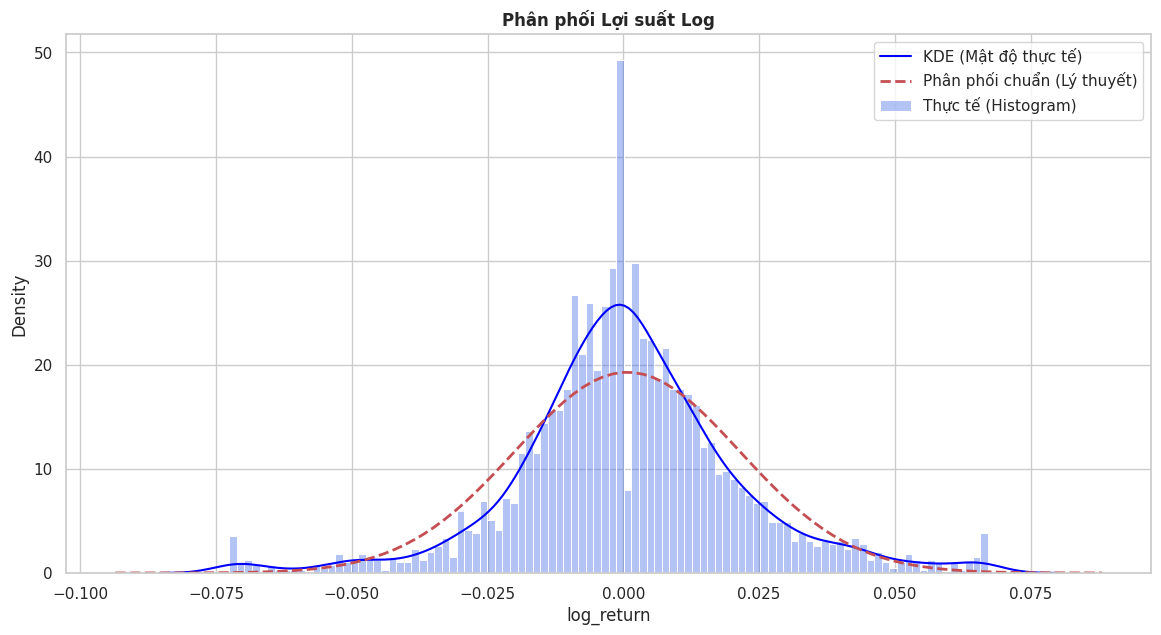

2026-04-08 13:23:42,844 - INFO -    + Vẽ Giá và Khối lượng...


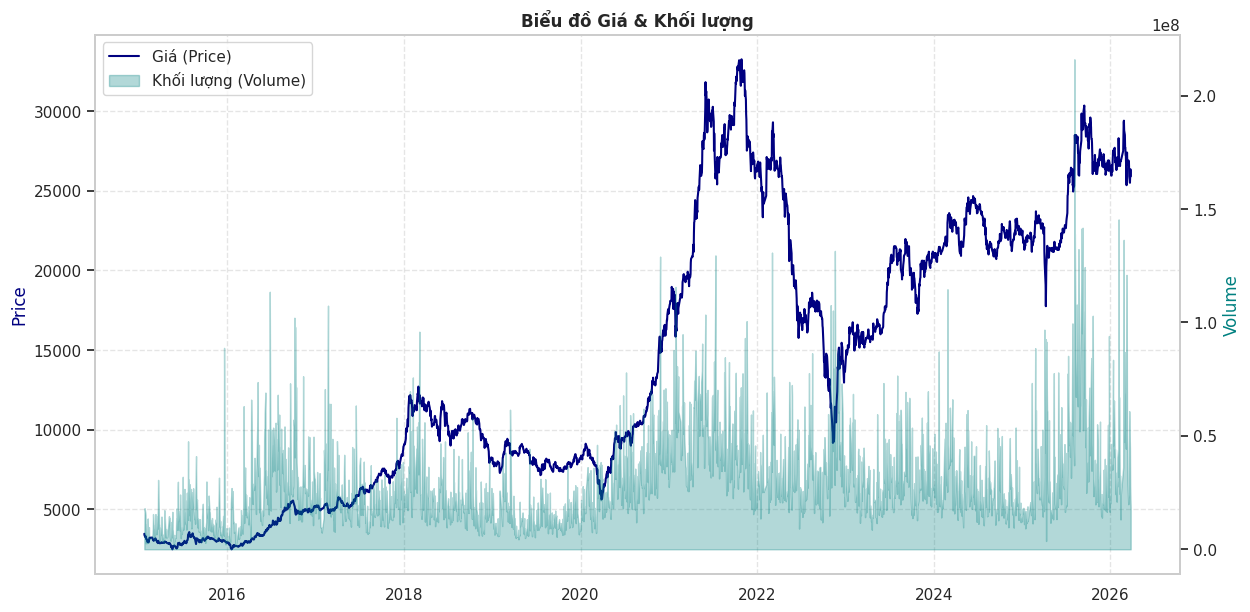

2026-04-08 13:23:43,255 - INFO -    + Vẽ Heatmap Tương quan...


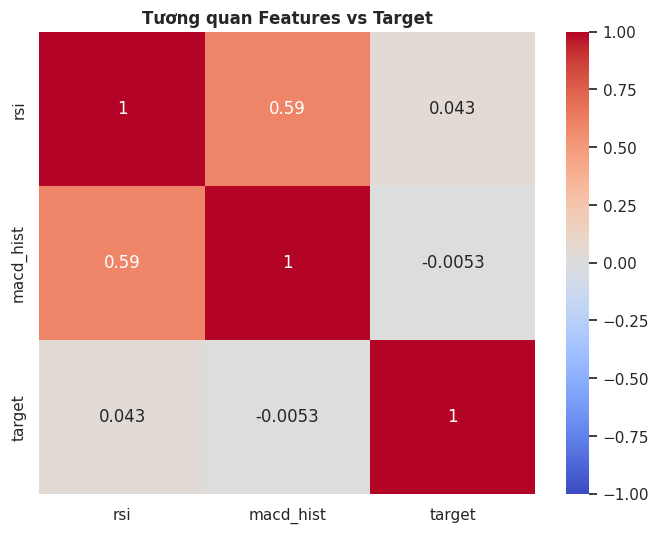

2026-04-08 13:23:43,452 - INFO -    + Vẽ Biểu đồ Mùa vụ (Seasonality)...
2026-04-08 13:23:43,485 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-08 13:23:43,496 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-08 13:23:44,187 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-08 13:23:44,197 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


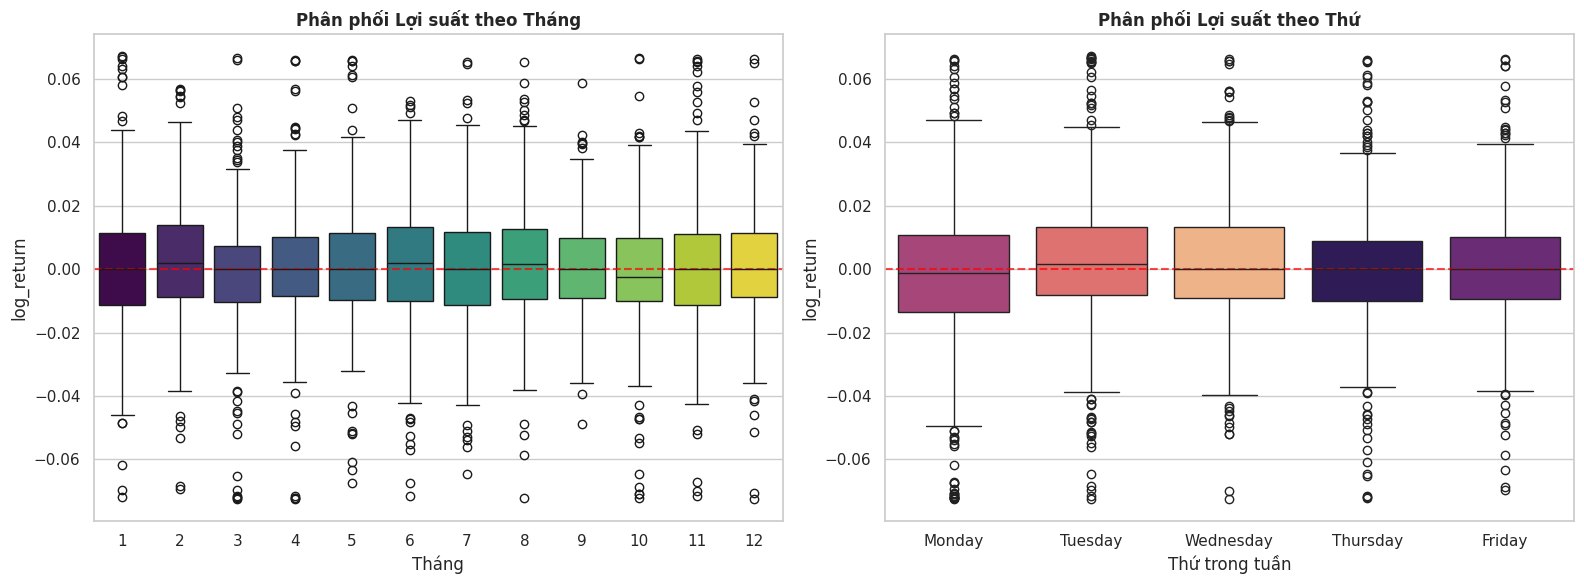

2026-04-08 13:23:44,459 - INFO - --- KẾT THÚC PRE-EDA ---

2026-04-08 13:23:44,460 - INFO - 
=== BẮT ĐẦU CHẠY VỚI ANOMALY THRESHOLD: 0.50% ===
2026-04-08 13:23:44,462 - INFO - --- BẮT ĐẦU PIPELINE XỬ LÝ DỮ LIỆU ---
2026-04-08 13:23:44,464 - INFO - [PROCESS] Sửa 2059 điểm giá bất thường (Interpolate).
2026-04-08 13:23:44,483 - INFO - [SPLIT] Train: 2200 | Test: 551
2026-04-08 13:23:44,492 - INFO - --- PIPELINE HOÀN TẤT ---
2026-04-08 13:23:44,493 - INFO -   [PostProcessingEDA] Performing basic checks...
2026-04-08 13:23:44,494 - INFO -   [PostProcessingEDA] X_train shape: (2200, 18)
2026-04-08 13:23:44,495 - INFO -   [PostProcessingEDA] X_test shape: (551, 18)
2026-04-08 13:23:44,495 - INFO -   [PostProcessingEDA] Checks complete.
2026-04-08 13:23:44,504 - INFO - [make_sequences] window=20 | Input: 2200 rows → Output: 2181 sequences | X_seq shape: (2181, 20, 16)
2026-04-08 13:23:44,507 - INFO - [make_sequences] window=20 | Input: 551 rows → Output: 532 sequences | X_seq shape: (532, 20,

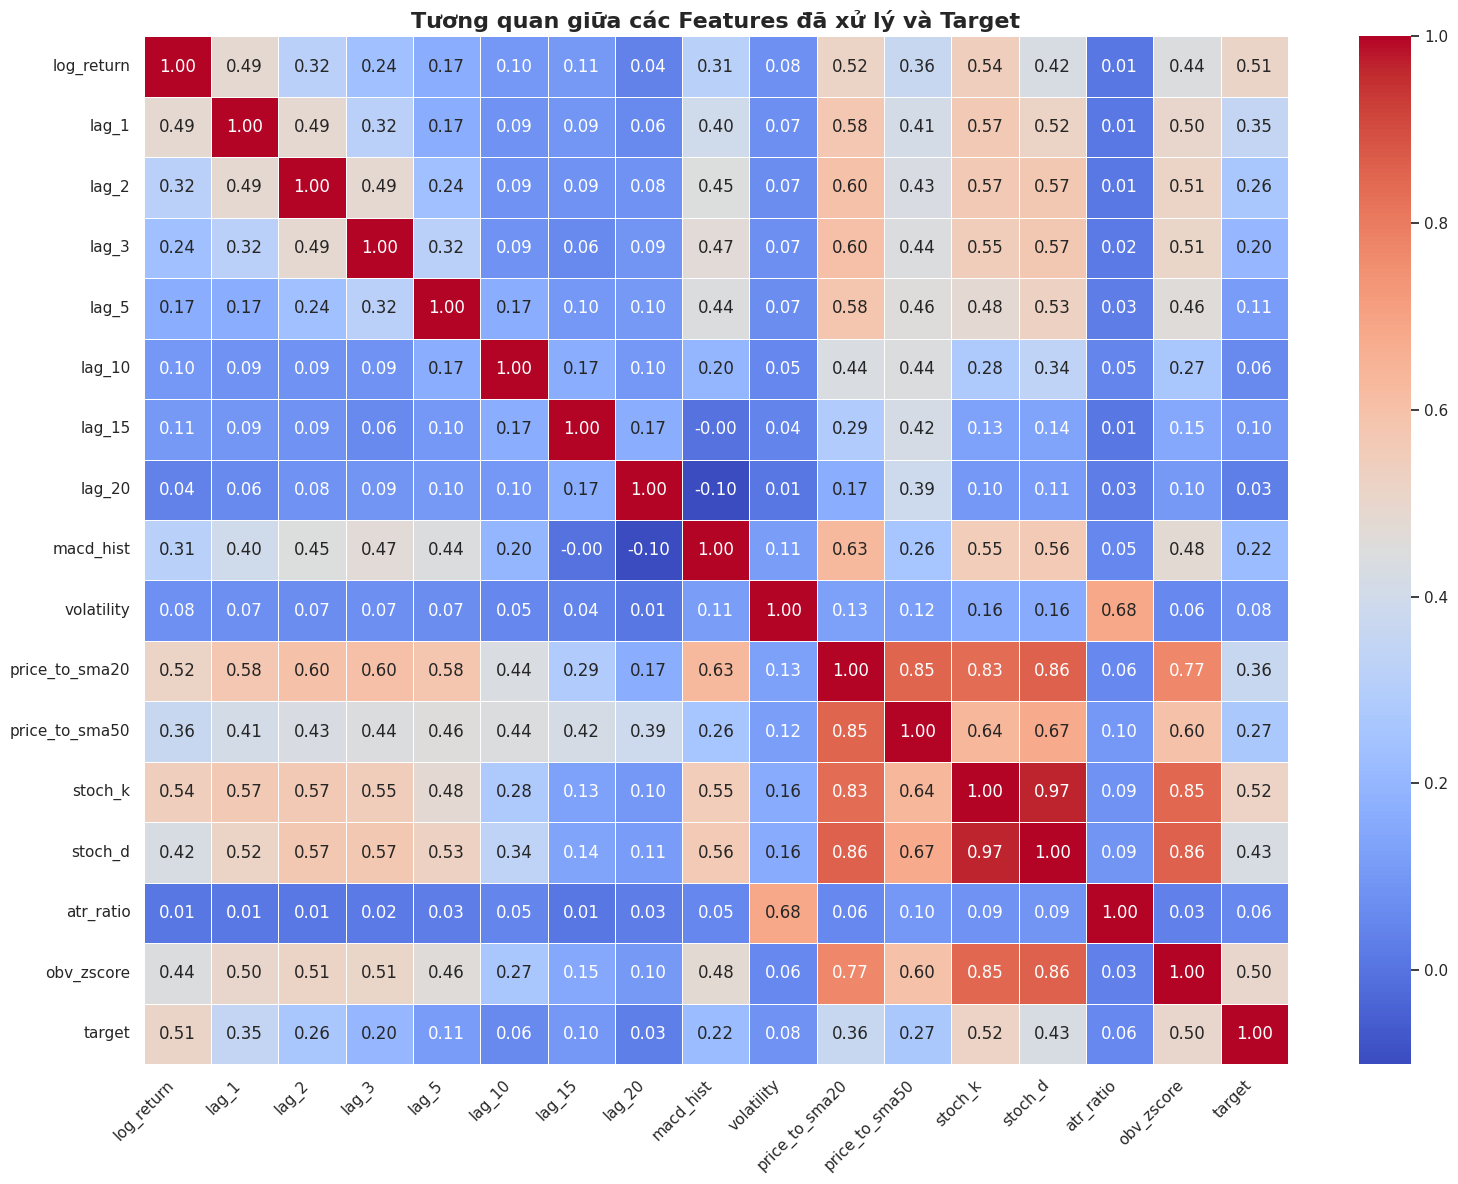

2026-04-08 13:23:45,166 - INFO - 
--- WALK-FORWARD VALIDATION (5 folds) ---
2026-04-08 13:23:45,168 - INFO - --- BẮT ĐẦU PIPELINE XỬ LÝ DỮ LIỆU ---
2026-04-08 13:23:45,170 - INFO - [PROCESS] Sửa 2059 điểm giá bất thường (Interpolate).
2026-04-08 13:23:45,190 - INFO - [SPLIT] Train: 2200 | Test: 551
2026-04-08 13:23:45,199 - INFO - --- PIPELINE HOÀN TẤT ---
2026-04-08 13:23:45,207 - INFO - [make_sequences] window=20 | Input: 461 rows → Output: 442 sequences | X_seq shape: (442, 20, 16)
2026-04-08 13:23:45,210 - INFO - [make_sequences] window=20 | Input: 458 rows → Output: 439 sequences | X_seq shape: (439, 20, 16)
2026-04-08 13:23:45,210 - INFO -    + Init Bidirectional Stacked LSTM + FocalLoss (Input: (20, 16), γ=2.0, α=0.5, Bi=True)...
2026-04-08 13:23:45,338 - INFO -    ✅ Stacked LSTM built. Params: 86,913
2026-04-08 13:23:57,088 - INFO -   [Fold 1] ROI=107.85% | Sharpe=3.115 | MaxDD=-18.38%
2026-04-08 13:23:57,098 - INFO - [make_sequences] window=20 | Input: 919 rows → Output: 900 s


--- BACKTESTING: LSTM ---
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


2026-04-08 13:32:49,245 - INFO - --- ĐÁNH GIÁ PHÂN LOẠI CHO LSTM ---
2026-04-08 13:32:49,248 - INFO -    [v3] Optimal threshold=0.589 (Prec≥0.8, Rec≥0.6, F1=0.7139)
2026-04-08 13:32:49,261 - INFO - Precision (class 1): 0.8011
2026-04-08 13:32:49,263 - INFO - --- KẾT THÚC ĐÁNH GIÁ PHÂN LOẠI CHO LSTM ---


   Vốn gốc:      100,000,000 VND
   Buy & Hold:   126,209,507.78 VND (ROI: 26.21 %)
   AI Strategy:  142,356,748.55 VND (ROI: 42.36 %)
   ✅ THÀNH CÔNG (Vượt thị trường +16,147,240.77 VND)
  [v2] Ngưỡng phân loại tối ưu: 0.589 (thay vì 0.500 mặc định)
  Accuracy Score : 0.7782
  Precision (lớp 1 - tín hiệu MUA): 0.8011  ← chỉ số chính

  Confusion Matrix:
[[269  36]
 [ 82 145]]

  Classification Report:
              precision    recall  f1-score   support

           0     0.7664    0.8820    0.8201       305
           1     0.8011    0.6388    0.7108       227

    accuracy                         0.7782       532
   macro avg     0.7837    0.7604    0.7655       532
weighted avg     0.7812    0.7782    0.7735       532



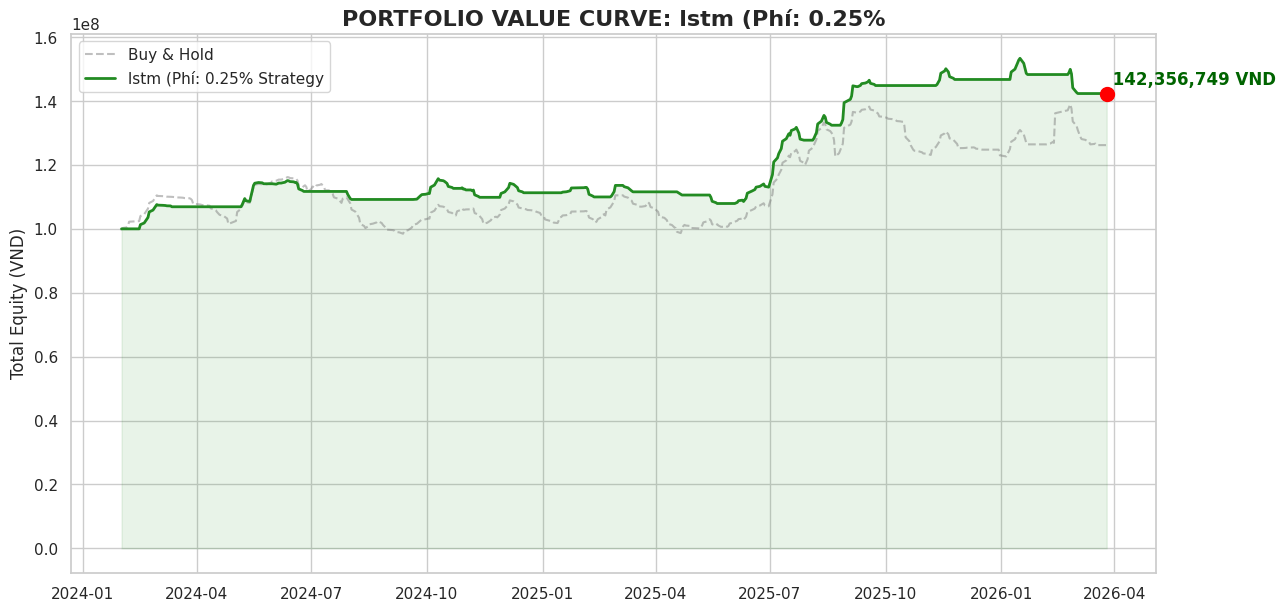

2026-04-08 13:32:49,488 - INFO -    [v3] Optimal threshold=0.589 (Prec≥0.8, Rec≥0.6, F1=0.7139)


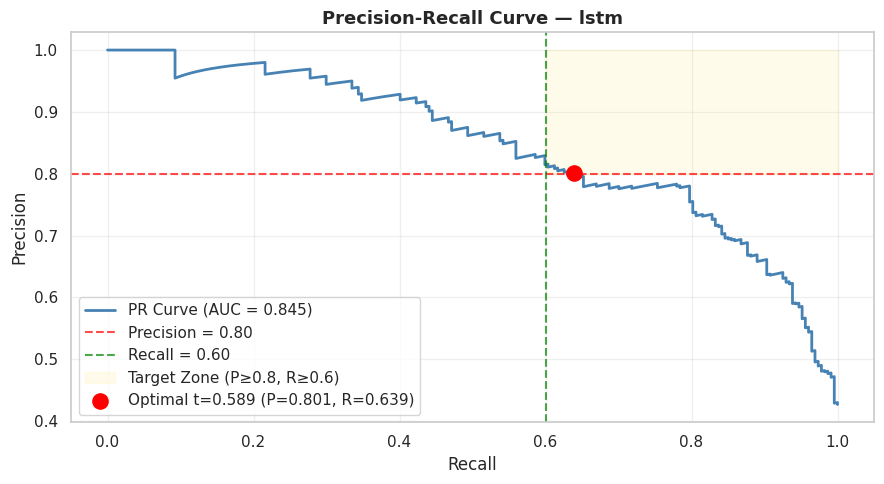

2026-04-08 13:32:49,653 - INFO - 
--- BENCHMARK (Threshold: 0.50%) ---
2026-04-08 13:32:49,655 - INFO - 
--- BENCHMARK STRATEGIES ---



  Chiến lược         |     ROI |  Sharpe |   MaxDD |  Trades
--------------------------------------------------------------------
  Buy & Hold         |  25.42% |   0.404 | -28.04% |       1
  Mean Reversion     |  10.34% |   0.288 | -21.83% |      10
  RSI Strategy       | -11.27% |  -0.278 | -26.50% |       3
  Momentum           | -21.02% |  -0.921 | -21.02% |      63
  SMA Crossover      | -23.22% |  -0.563 | -41.07% |       7


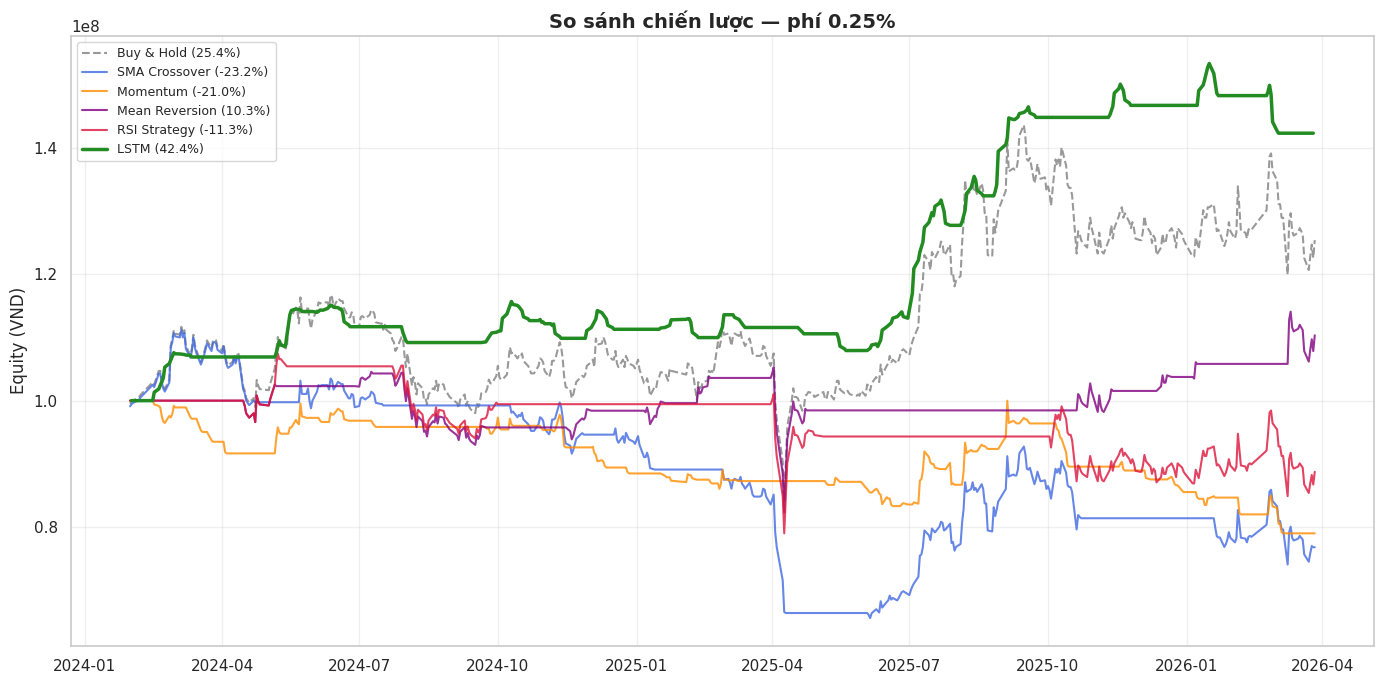

2026-04-08 13:32:49,951 - INFO - 
✅ CHƯƠNG TRÌNH HOÀN TẤT.


In [28]:
import pandas as pd
from typing import Optional, Dict, Any, Tuple, List
import numpy as np # Import numpy for np.maximum.accumulate, np.sign, etc.
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
import logging

# LƯU Ý QUAN TRỌNG: Nếu gặp lỗi NameError cho các lớp (ví dụ: StockLoader),
# Vui lòng chạy TẤT CẢ các ô mã code từ đầu notebook đến ô này trước khi chạy lại.
# Các lớp cần được định nghĩa (thực thi) trước khi chúng có thể được sử dụng.

from dataclasses import dataclass, field

# Placeholder for PostProcessingEDA to resolve NameError
# If you have a full definition for this class, please provide it.
class PostProcessingEDA:
    def __init__(self, X_train, X_test):
        self.X_train = X_train
        self.X_test = X_test

    def run_all_checks(self):
        logger = logging.getLogger(__name__) # Ensure logger is accessible within the method
        logger.info("  [PostProcessingEDA] Performing basic checks...")
        if self.X_train is None or self.X_test is None:
            logger.warning("  [PostProcessingEDA] X_train or X_test is None, skipping checks.")
            return

        # Example checks:
        # Check for NaNs
        if isinstance(self.X_train, pd.DataFrame) and self.X_train.isnull().sum().sum() > 0:
            logger.warning("  [PostProcessingEDA] NaNs found in X_train.")
        elif isinstance(self.X_train, np.ndarray) and np.isnan(self.X_train).sum() > 0:
            logger.warning("  [PostProcessingEDA] NaNs found in X_train.")

        if isinstance(self.X_test, pd.DataFrame) and self.X_test.isnull().sum().sum() > 0:
            logger.warning("  [PostProcessingEDA] NaNs found in X_test.")
        elif isinstance(self.X_test, np.ndarray) and np.isnan(self.X_test).sum() > 0:
            logger.warning("  [PostProcessingEDA] NaNs found in X_test.")

        # Check shapes
        logger.info(f"  [PostProcessingEDA] X_train shape: {self.X_train.shape}")
        logger.info(f"  [PostProcessingEDA] X_test shape: {self.X_test.shape}")

        logger.info("  [PostProcessingEDA] Checks complete.")



# ==========================================
# CẤU HÌNH CHẠY (USER CONFIGURATION)
# ==========================================
ENABLE_EDA         = True   # True: Vẽ biểu đồ khám phá ban đầu
ENABLE_POST_EDA     = False   # True: Vẽ biểu đồ kiểm tra sau xử lý
ENABLE_TRAINING    = True    # True: Huấn luyện lại Model
ENABLE_WALK_FORWARD = True   # True: Chạy Walk-Forward Validation (5 folds)
ENABLE_FULL_CORRELATION = True # NEW: Vẽ biểu đồ tương quan đầy đủ các features

# ✅ Đồng nhất 1 mức phí 0.25% cho tất cả chiến lược (LSTM + Benchmark)
TRANSACTION_COST   = 0.0025  # 0.25% — phí môi giới + thuế giao dịch

# Số ngày nhìn lại (sequence window) cho LSTM
# LSTM sẽ nhận input shape (WINDOW_SIZE, n_features) thay vì (1, n_features)
# Giá trị 20 = ~1 tháng giao dịch — đủ để học ngắn-trung hạn
WINDOW_SIZE = 20

ANOMALY_THRESHOLDS = [0.005]  # Ngưỡng phát hiện bất thường


# ==========================================
# EXPERIMENT CONTEXT — thay thế global vars
# ==========================================
@dataclass
class ExperimentContext:
    """
    Đóng gói toàn bộ state của một lần thí nghiệm.
    Thay thế pattern anti-pattern dùng global variables.
    Truyền object này giữa các hàm thay vì dùng global.
    """
    raw_df:   Optional[pd.DataFrame]   = None
    builder:  Optional[Any]            = None
    X_train:  Optional[np.ndarray]     = None  # 3D array (N, W, F)
    y_train:  Optional[pd.Series]      = None
    X_test:   Optional[np.ndarray]     = None  # 3D array (N, W, F)
    y_test:   Optional[pd.Series]      = None
    original_log_return_test: Optional[pd.Series] = None
    X_train_for_correlation: Optional[pd.DataFrame] = None # New field
    all_benchmark_results: List        = field(default_factory=list)

    # (Không còn backward-compat properties — truy cập trực tiếp qua _ctx.raw_df, v.v.)


# Biến module-level DUY NHẤT — chỉ để cell 15/16 truy cập kết quả sau khi main() chạy xong
_ctx: Optional[ExperimentContext] = None

def main() -> ExperimentContext:
    """
    Hàm điều phối chính (Orchestrator) của hệ thống Ultima.
    Thực hiện tuần tự: Load -> EDA -> Pipeline -> WalkForward -> Model -> Backtest.

    Returns:
        ExperimentContext: toàn bộ kết quả thí nghiệm (không dùng global).
    """
    global _ctx
    set_global_seed(249)

    ctx = ExperimentContext()
    logger = logging.getLogger(__name__) # Ensure logger is accessible in main
    logger.info(">>> KHỞI CHẠY HỆ THỐNG ULTIMA TOÀN DIỆN...")

    # GIAI ĐOẠN KHỞI TẠO DỮ LIỆU
    ctx.raw_df = _step_load_data()
    if ctx.raw_df is None:
        return ctx

    if ENABLE_EDA:
        logger.info("\n--- ĐANG VẼ BIỂU ĐỒ KHÁM PHÁ (PRE-EDA)...")
        _step_run_eda(ctx.raw_df)
    else:
        logger.info(">>> Đã bỏ qua bước Pre-EDA (ENABLE_EDA = False).")

    for anomaly_th in ANOMALY_THRESHOLDS:
        logger.info(f"\n=== BẮT ĐẦU CHẠY VỚI ANOMALY THRESHOLD: {anomaly_th*100:.2f}% ===")

        # PIPELINE
        data_pack = _step_run_pipeline(ctx.raw_df, anomaly_threshold=anomaly_th)
        if not data_pack:
            logger.error(f"Pipeline thất bại với anomaly_threshold {anomaly_th}. Bỏ qua...")
            continue

        ctx.X_train, ctx.y_train, ctx.X_test, ctx.y_test, ctx.original_log_return_test, ctx.X_train_for_correlation = data_pack

        # POST-EDA
        if ENABLE_POST_EDA:
            checker = PostProcessingEDA(ctx.X_train, ctx.X_test)
            checker.run_all_checks()
        else:
            logger.info(">>> Đã bỏ qua bước Post-EDA (ENABLE_POST_EDA = False).")

        # FULL CORRELATION PLOT (after feature engineering)
        if ENABLE_FULL_CORRELATION:
            logger.info("\n--- ĐANG VẼ BIỂU ĐỒ TƯƠNG QUAN ĐẦY ĐỦ CÁC FEATURES ---")
            _step_plot_full_correlation(ctx.X_train_for_correlation, ctx.y_train)
        else:
            logger.info(">>> Đã bỏ qua bước Vẽ Biểu đồ Tương quan Đầy đủ Features.")

        # WALK-FORWARD VALIDATION
        if ENABLE_WALK_FORWARD:
            logger.info("\n--- WALK-FORWARD VALIDATION (5 folds) ---")
            wf_summary = _step_walk_forward_validate(
                ctx.raw_df, anomaly_th, n_splits=5
            )
            logger.info(f"Walk-Forward trung bình: ROI={wf_summary['mean_roi']:.2f}% "
                        f"| Sharpe={wf_summary['mean_sharpe']:.3f} "
                        f"| MaxDD={wf_summary['mean_maxdd']:.2%} "
                        f"[std ROI=±{wf_summary['std_roi']:.2f}%]")

        # MODELING (full train set)
        ctx.builder = _step_train_models(ctx.X_train, ctx.y_train)

        # BACKTESTING — ✅ dùng 1 mức phí đồng nhất 0.25%
        logger.info(f"\n--- BACKTESTING với phí đồng nhất {TRANSACTION_COST*100:.2f}% ---")
        lstm_df_res, lstm_metrics = _step_run_backtest(
            ctx.builder, ctx.X_test, ctx.y_test,
            transaction_cost=TRANSACTION_COST,
            ctx_original_log_return=ctx.original_log_return_test
        )

        # BENCHMARK — ✅ cùng phí 0.25% với LSTM
        logger.info(f"\n--- BENCHMARK (Threshold: {anomaly_th*100:.2f}%) ---")
        benchmark = BenchmarkStrategies(
            df_raw=ctx.raw_df,
            initial_capital=100_000_000,
            transaction_cost=TRANSACTION_COST  # ✅ đồng nhất
        )
        summary_df = benchmark.run_all(test_start_date=ctx.y_test.index[0])

        if lstm_metrics:
            lstm_row = {k: v for k, v in lstm_metrics.items() if k != 'equity'}
            summary_df = pd.concat(
                [summary_df, pd.DataFrame([lstm_row])], ignore_index=True
            ).sort_values('roi', ascending=False).reset_index(drop=True)

        ctx.all_benchmark_results.append((anomaly_th, summary_df))

        if lstm_df_res is not None:
            benchmark.plot_all(lstm_equity=lstm_df_res['equity_curve_ai'])

    _ctx = ctx  # lưu để cell 15/16 truy cập
    logger.info("\n✅ CHƯƠNG TRÌNH HOÀN TẤT.")
    return ctx


# --- CÁC HÀM HỖ TRỢ (HELPER FUNCTIONS) ---


def make_sequences(
    X: pd.DataFrame,
    y: pd.Series,
    window_size: int,
    extra_cols: Optional[List[str]] = None
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray]]:
    """
    Tạo chuỗi (sequence windows) cho LSTM từ dữ liệu phẳng.

    Nguyên lý:
        Sample i → X_seq[i] = X[i : i+window_size]   (window_size ngày liên tiếp)
                   y_seq[i] = y[i + window_size - 1]  (nhãn của ngày CUỐI window)

    Args:
        X           : DataFrame features (đã scale), chưa bao gồm extra_cols
        y           : Series target (0/1)
        window_size : Số bước thời gian trong mỗi sequence
        extra_cols  : Các cột cần giữ lại song song (ví dụ: original_log_return)
                      — không đưa vào X_seq, chỉ cần căn chỉnh index

    Returns:
        X_seq       : np.ndarray shape (N-window+1, window_size, n_features)
        y_seq       : np.ndarray shape (N-window+1,)
        extra_arr   : np.ndarray shape (N-window+1, len(extra_cols)) hoặc None
    """
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    feature_cols = [c for c in X.columns if c not in (extra_cols or [])]
    X_vals = X[feature_cols].values
    y_vals = y.values

    n = len(X_vals)
    if n < window_size:
        raise ValueError(f"Dữ liệu ({n} rows) nhỏ hơn window_size ({window_size})")

    n_seq = n - window_size + 1
    X_seq = np.stack([X_vals[i : i + window_size] for i in range(n_seq)])  # (N_seq, W, F)
    y_seq = y_vals[window_size - 1 :]                                        # căn chỉnh về ngày cuối window

    extra_arr = None
    if extra_cols:
        # The X passed here is X_test_feat, which does not contain 'original_log_return'.
        # So, this line causes a KeyError. Remove this logic from here.
        pass # This is no longer needed

    logger.info(
        f"[make_sequences] window={window_size} | "
        f"Input: {n} rows → Output: {n_seq} sequences | "
        f"X_seq shape: {X_seq.shape}"
    )
    return X_seq, y_seq, extra_arr # extra_arr will always be None now if extra_cols was passed to make_sequences, which we won't be doing for X_test_seq.

def _step_load_data() -> Optional[pd.DataFrame]:
    """Bước 1: Tải và làm sạch dữ liệu thô."""
    loader = StockLoader()
    if not os.path.exists('HPG_fixed.csv'):
        if not loader.upload_file_colab():
            return None
    return loader.load_and_clean()


def _step_run_eda(df: pd.DataFrame) -> None:
    """Bước 2: Vẽ biểu đồ khám phá."""
    viz = StockVisualizer(df)
    viz.run_eda()


def _step_run_pipeline(
    df: pd.DataFrame,
    anomaly_threshold: float = 0.15
) -> Optional[Tuple]:
    """
    Bước 3: Chạy Pipeline và chuẩn bị dữ liệu train/test.
    ✅ Anti-leakage: scaler fit CHỈ trên train set (xử lý trong StockPipeline._scale_data).
    Output: (X_train_3D, y_train, X_test_3D, y_test, original_log_return_test)
    X_train/X_test là np.ndarray 3D shape (N, WINDOW_SIZE, n_features).
    """
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    pipeline = StockPipeline(df)
    lags = [int(c.split('_')[1]) for c in StockPipeline.FEATURE_COLS if c.startswith('lag_')]
    result = pipeline.run_pipeline(anomaly_threshold=anomaly_threshold, lags=lags)

    if result[0] is None:
        return None

    scaled_train, scaled_test, _ = result

    checker = PostProcessingEDA(scaled_train, scaled_test)
    checker.run_all_checks()

    target_col = 'target'
    features_to_exclude = [target_col, 'original_log_return']
    features = [c for c in scaled_train.columns if c not in features_to_exclude]

    # ── Tạo sequence windows cho LSTM ──────────────────────────────────────
    # Anti-leakage: make_sequences chỉ dùng dữ liệu đã được scale trên train set
    X_train_feat = scaled_train[features]
    y_train_raw  = scaled_train[target_col]
    X_test_feat  = scaled_test[features]
    y_test_raw   = scaled_test[target_col]

    X_train_seq, y_train_seq, _ = make_sequences(
        X_train_feat, y_train_raw, window_size=WINDOW_SIZE
    )
    # Remove extra_cols from make_sequences for X_test, as X_test_feat does not contain it
    X_test_seq, y_test_seq, _ = make_sequences(
        X_test_feat, y_test_raw, window_size=WINDOW_SIZE
    )

    # Wrap lại thành Series/DataFrame để tương thích với các bước sau
    # Lấy index căn chỉnh (ngày cuối mỗi window)
    train_index = scaled_train.index[WINDOW_SIZE - 1:]
    test_index  = scaled_test.index[WINDOW_SIZE - 1:]

    y_train = pd.Series(y_train_seq, index=train_index, name=target_col)
    y_test  = pd.Series(y_test_seq,  index=test_index,  name=target_col)

    # X_train, X_test giờ là np.ndarray 3D — được truyền thẳng vào model
    # Gói thêm original_log_return riêng để BacktestingPipeline dùng tính PnL
    X_train = X_train_seq  # shape: (N_train_seq, WINDOW_SIZE, n_features)
    X_test  = X_test_seq   # shape: (N_test_seq,  WINDOW_SIZE, n_features)

    # Lưu original_log_return cho backtest (căn chỉnh cùng index với y_test)
    # Directly extract original_log_return from scaled_test as it is guaranteed to be there
    original_log_return_test = pd.Series(
        scaled_test['original_log_return'].iloc[WINDOW_SIZE - 1:].values,
        index=test_index, name='original_log_return'
    )

    # Prepare 2D DataFrame for correlation plotting
    X_train_for_correlation = X_train_feat.loc[train_index]

    n_test_days = len(y_test)
    logger.info(f"[INFO] Test set: {n_test_days} sequences "
                f"({y_test.index[0].date()} → {y_test.index[-1].date()}) "
                f"| X_test shape: {X_test.shape}")

    return X_train, y_train, X_test, y_test, original_log_return_test, X_train_for_correlation


def _step_plot_full_correlation(X_train: pd.DataFrame, y_train: pd.Series) -> None:
    """Bước mới: Vẽ biểu đồ Heatmap tương quan cho tất cả các features đã xử lý."""
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    logger.info("   + Vẽ Heatmap Tương quan đầy đủ Features và Target...")
    # Kết hợp X_train và y_train để tính toán tương quan
    df_combined = X_train.copy()
    df_combined['target'] = y_train

    plt.figure(figsize=(16, 12)) # Tăng kích thước để dễ đọc hơn
    # Chọn chỉ những cột đã có trong StockPipeline.FEATURE_COLS + 'target'
    cols_to_plot = [col for col in StockPipeline.FEATURE_COLS if col in df_combined.columns] + ['target']

    # Kiểm tra nếu có đủ cột để vẽ heatmap
    if len(cols_to_plot) < 2:
        logger.warning("Không đủ cột để vẽ biểu đồ tương quan đầy đủ.")
        return

    sns.heatmap(df_combined[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Tương quan giữa các Features đã xử lý và Target', fontweight='bold', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def _step_walk_forward_validate(
    raw_df: pd.DataFrame,
    anomaly_threshold: float,
    n_splits: int = 5
) -> Dict[str, float]:
    """
    Bước 3b: Walk-Forward Validation với TimeSeriesSplit.

    Ý nghĩa: Thay vì đánh giá mô hình 1 lần trên 1 test set duy nhất,
    ta chia dữ liệu thành n_splits fold theo thứ tự thời gian.
    Mỗi fold train trên dữ liệu cũ hơn, test trên dữ liệu mới hơn.
    → Kết quả đáng tin cậy hơn về mặt thống kê (có mean ± std).

    Returns:
        dict: mean/std của ROI, Sharpe, MaxDD qua các fold.
    """
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    pipeline_tmp = StockPipeline(raw_df)
    lags = [int(c.split('_')[1]) for c in StockPipeline.FEATURE_COLS if c.startswith('lag_')]
    result = pipeline_tmp.run_pipeline(anomaly_threshold=anomaly_threshold, lags=lags)
    if result[0] is None:
        return {}

    scaled_train, scaled_test, _ = result
    # Combine train and test for the full dataset to split for walk-forward
    full_scaled = pd.concat([scaled_train, scaled_test])

    target_col  = 'target'
    excl        = [target_col, 'original_log_return']
    features    = [c for c in full_scaled.columns if c not in excl]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics: List[Dict] = []

    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(full_scaled), 1):
        X_tr_fold = full_scaled.iloc[train_idx][features]
        y_tr_fold = full_scaled.iloc[train_idx][target_col]
        lr_tr_fold = full_scaled.iloc[train_idx]['original_log_return'] # Keep for potential sequence check

        X_te_fold = full_scaled.iloc[test_idx][features]
        y_te_fold = full_scaled.iloc[test_idx][target_col]
        lr_te_fold = full_scaled.iloc[test_idx]['original_log_return']

        if len(X_tr_fold) < WINDOW_SIZE + 10 or len(X_te_fold) < WINDOW_SIZE:
            logger.info(f"  [Fold {fold_i}] Quá ít dữ liệu cho training/testing với window_size={WINDOW_SIZE}, bỏ qua.")
            continue

        # 1. Scaler fit CHỈ trên fold train
        fold_scaler = MinMaxScaler(feature_range=(0, 1))
        X_tr_scaled = fold_scaler.fit_transform(X_tr_fold)
        X_te_scaled = fold_scaler.transform(X_te_fold)

        # Convert back to DataFrame for make_sequences (if needed, otherwise can pass numpy array directly)
        X_tr_scaled_df = pd.DataFrame(X_tr_scaled, columns=features, index=X_tr_fold.index)
        X_te_scaled_df = pd.DataFrame(X_te_scaled, columns=features, index=X_te_fold.index)

        # 2. Xây dựng sequence windows TRƯỚC KHI fit model
        X_tr_3d, y_tr_seq, _ = make_sequences(X_tr_scaled_df, y_tr_fold, window_size=WINDOW_SIZE)
        X_te_3d, y_te_seq, _ = make_sequences(X_te_scaled_df, y_te_fold, window_size=WINDOW_SIZE)

        # Align original_log_return with y_te_seq
        lr_te_seq = lr_te_fold.iloc[WINDOW_SIZE - 1:].values

        if len(X_tr_3d) == 0 or len(X_te_3d) == 0:
            logger.info(f"  [Fold {fold_i}] Không đủ sequence sau make_sequences, bỏ qua.")
            continue

        # 3. Build model (chỉ 1 lần)
        fold_builder = StockModelBuilder()
        fold_builder.build_lstm(
            input_shape=(WINDOW_SIZE, X_tr_3d.shape[2]),
            units=64, dropout=0.2, lr=0.001,
            focal_gamma=2.0, focal_alpha=0.50, # Adjusted to default for consistency
            use_bidirectional=True
        )
        model = fold_builder.models['lstm']

        # Define callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
        ]

        # Compute class weights (aligned with main training)
        cw = {0: 1.0, 1: 0.60}

        # 4. Huấn luyện model (chỉ 1 lần với 3D sequence data)
        # Using a simple train/val split for the fold itself for callbacks
        split_fold_idx = int(len(X_tr_3d) * 0.9)
        X_tr_fit, y_tr_fit = X_tr_3d[:split_fold_idx], y_tr_seq[:split_fold_idx]
        X_val_fit, y_val_fit = X_tr_3d[split_fold_idx:], y_tr_seq[split_fold_idx:]

        model.fit(
            X_tr_fit, y_tr_fit,
            validation_data=(X_val_fit, y_val_fit),
            epochs=100, # Increased epochs
            batch_size=32,
            callbacks=callbacks,
            class_weight=cw,
            verbose=0,
            shuffle=False
        )

        # Predict
        preds = model.predict(X_te_3d, verbose=0).flatten()

        # Tính signal và equity đơn giản
        # Modified signal threshold to 0.5
        signals = (preds > 0.5).astype(float)
        signals = pd.Series(signals).shift(1).fillna(0).values

        # Ensure consistent length between signals and lr_te_seq
        min_len = min(len(signals), len(lr_te_seq))
        signals = signals[:min_len]
        lr_te_seq = lr_te_seq[:min_len]

        trades  = np.abs(np.diff(signals, prepend=0))
        net_ret = signals * lr_te_seq - trades * TRANSACTION_COST
        equity  = 100_000_000 * np.exp(np.cumsum(net_ret))

        roi    = (equity[-1] - 100_000_000) / 100_000_000 * 100
        sharpe = (net_ret.mean() / net_ret.std() * np.sqrt(252)
                  if net_ret.std() > 0 else 0)
        maxdd  = ((equity - np.maximum.accumulate(equity)) / np.maximum.accumulate(equity)).min()

        fold_metrics.append({'roi': roi, 'sharpe': sharpe, 'maxdd': maxdd})
        logger.info(f"  [Fold {fold_i}] ROI={roi:.2f}% | Sharpe={sharpe:.3f} | MaxDD={maxdd:.2%}")

    if not fold_metrics:
        return {'mean_roi': 0, 'std_roi': 0, 'mean_sharpe': 0, 'mean_maxdd': 0}

    rois    = [m['roi']    for m in fold_metrics]
    sharpes = [m['sharpe'] for m in fold_metrics]
    maxdds  = [m['maxdd']  for m in fold_metrics]

    return {
        'mean_roi':    float(np.mean(rois)),
        'std_roi':     float(np.std(rois)),
        'mean_sharpe': float(np.mean(sharpes)),
        'mean_maxdd':  float(np.mean(maxdds)),
    }


def _step_train_models(X_train: np.ndarray, y_train: pd.Series) -> StockModelBuilder:
    """Bước 4: Khởi tạo và huấn luyện đa mô hình."""
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    logger.info("\n>>> MODELING PHASE...")

    builder = StockModelBuilder()
    # X_train là 3D array (N, WINDOW_SIZE, n_features)
    input_shape = (X_train.shape[1], X_train.shape[2])  # (WINDOW_SIZE, n_features)
    builder.build_lstm(
        input_shape=input_shape,
        units=128, dropout=0.3, lr=0.0005,
        focal_gamma=2.0, focal_alpha=0.50,
        use_bidirectional=True
    )

    split_idx = int(len(X_train) * 0.9)
    X_tr, y_tr   = X_train[:split_idx], y_train.iloc[:split_idx]
    X_val, y_val = X_train[split_idx:],  y_train.iloc[split_idx:]

    builder.train_all_models(X_tr, y_tr, X_val, y_val)
    logger.info("✅ Đã hoàn tất huấn luyện toàn bộ models.")
    return builder


def _step_run_backtest(
    builder: StockModelBuilder,
    X_test: np.ndarray,
    y_test: pd.Series,
    transaction_cost: float = 0.0025,
    ctx_original_log_return: Optional[pd.Series] = None
) -> Tuple[Optional[pd.DataFrame], Optional[Dict[str, Any]]]:
    """Bước 5: Giả lập giao dịch và xếp hạng."""
    logger = logging.getLogger(__name__) # Ensure logger is accessible here
    logger.info("\n>>> BACKTESTING PHASE...")

    initial_capital = 100_000_000
    backtester = BacktestingPipeline(
        initial_capital=initial_capital,
        transaction_cost=transaction_cost
    )

    lstm_df_res  = None
    lstm_metrics = None

    for name, model in builder.models.items():
        logger.info(f"\n↔ Backtest {name.upper()} — phí {transaction_cost*100:.2f}%")

        df_res, ai_equity, market_equity = backtester.run_simulation(
            model=model, X_test=X_test, y_test=y_test,
            original_log_return=ctx_original_log_return,
            model_name=name
        )
        backtester.plot_portfolio_growth(df_res, model_name=f"{name} (Phí: {transaction_cost*100:.2f}%")
        # ✅ [v3] Vẽ Precision-Recall curve
        backtester.plot_precision_recall_curve(df_res['actual_return'], df_res['predicted_return'], model_name=name)

        if name == 'lstm':
            lstm_df_res = df_res
            net_ret = df_res['strategy_net_return']
            equity  = df_res['equity_curve_ai']

            sharpe_val  = (net_ret.mean() / net_ret.std() * np.sqrt(252)
                           if net_ret.std() > 0 else 0)
            max_dd_val  = ((equity - equity.cummax()) / equity.cummax()).min()
            n_trades_val = df_res['signal'].diff().abs().sum() / 2

            lstm_metrics = {
                'name':     name,
                'final':    ai_equity,
                'roi':      (ai_equity - initial_capital) / initial_capital * 100,
                'sharpe':   round(sharpe_val, 3),
                'max_dd':   round(max_dd_val, 4),
                'n_trades': int(n_trades_val),
                'equity':   equity,
            }

    return lstm_df_res, lstm_metrics



# --- ENTRY POINT ---
if __name__ == "__main__":
    ctx = main()


In [31]:
import pandas as pd

if '_ctx' not in globals() or _ctx is None or _ctx.X_train_for_correlation is None:
    print("⛔ Context không hợp lệ. Vui lòng chạy lại hàm main() trước.")
else:
    # Kết hợp X_train và y_train để tính toán tương quan
    df_combined = _ctx.X_train_for_correlation.copy()
    df_combined['target'] = _ctx.y_train.loc[_ctx.X_train_for_correlation.index] # Align target with correlation features

    # Tính ma trận tương quan
    correlation_matrix = df_combined.corr()

    # Lấy cột tương quan với 'target'
    target_correlations = correlation_matrix['target'].drop('target') # Loại bỏ tương quan với chính nó

    # Sắp xếp theo giá trị tuyệt đối để tìm các biến có tương quan mạnh nhất
    sorted_correlations = target_correlations.abs().sort_values(ascending=False)

    # In ra 5 biến có tương quan cao nhất
    top_n = 5
    print(f"\nTop {top_n} biến có tương quan cao nhất với 'target':")
    for var, abs_corr in sorted_correlations.head(top_n).items():
        actual_corr = target_correlations[var]
        print(f"- {var}: {actual_corr:.4f} (Giá trị tuyệt đối: {abs_corr:.4f})")



Top 5 biến có tương quan cao nhất với 'target':
- stoch_k: 0.5194 (Giá trị tuyệt đối: 0.5194)
- log_return: 0.5141 (Giá trị tuyệt đối: 0.5141)
- obv_zscore: 0.4972 (Giá trị tuyệt đối: 0.4972)
- stoch_d: 0.4269 (Giá trị tuyệt đối: 0.4269)
- price_to_sma20: 0.3638 (Giá trị tuyệt đối: 0.3638)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


2026-04-08 13:33:27,956 - INFO -    [v3] Optimal threshold=0.589 (Prec≥0.8, Rec≥0.6, F1=0.7139)


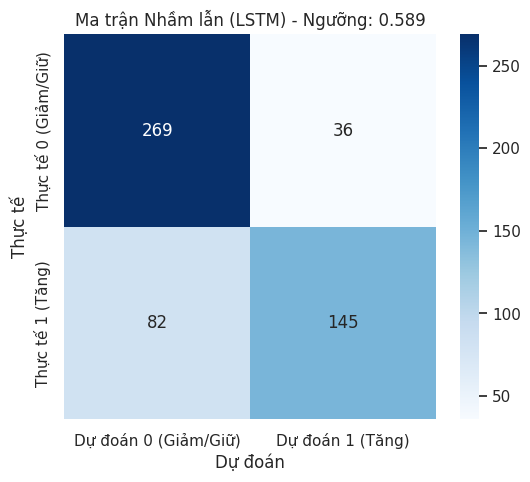

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if '_ctx' not in globals() or _ctx is None or _ctx.builder is None:
    print("⛔ Context không hợp lệ. Vui lòng chạy lại hàm main() trước.")
else:
    lstm_model = _ctx.builder.models['lstm']
    # X_test đã là np.ndarray 3D (N, WINDOW_SIZE, n_features) từ make_sequences()
    X_test_3d  = _ctx.X_test
    y_test     = _ctx.y_test

    # Make predictions — X_test_3d đúng shape rồi, truyền thẳng
    y_pred_proba = lstm_model.predict(X_test_3d).flatten()

    # Instantiate BacktestingPipeline to use find_optimal_threshold
    backtester = BacktestingPipeline() # Default capital and cost are fine for threshold finding
    optimal_t = backtester.find_optimal_threshold(y_test, y_pred_proba,
                                                  min_precision=0.80, min_recall=0.60)

    y_pred_labels = (y_pred_proba > optimal_t).astype(int)

    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_labels)

    # Plotting the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dự đoán 0 (Giảm/Giữ)', 'Dự đoán 1 (Tăng)'],
                yticklabels=['Thực tế 0 (Giảm/Giữ)', 'Thực tế 1 (Tăng)'])
    plt.title(f'Ma trận Nhầm lẫn (LSTM) - Ngưỡng: {optimal_t:.3f}')
    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')
    plt.show()

In [32]:
import pandas as pd

# Lấy kết quả từ ExperimentContext (_ctx được set bởi main())
if '_ctx' not in globals() or _ctx is None or not _ctx.all_benchmark_results:
    print("⛔ Cần chạy main() trước!")
else:
    all_benchmark_results = _ctx.all_benchmark_results

    all_results_for_display = []

    for anomaly_th, summary_df in all_benchmark_results:
        df_subset = summary_df[['name', 'roi', 'sharpe', 'max_dd']].copy()
        df_subset['anomaly_threshold'] = anomaly_th
        all_results_for_display.append(df_subset)

    final_comparison_df = pd.concat(all_results_for_display, ignore_index=True)
    final_comparison_df['max_dd'] = final_comparison_df['max_dd'] * 100

    final_comparison_df.rename(columns={
        'name':             'Chiến lược',
        'roi':              'ROI (%)',
        'sharpe':           'Sharpe Ratio',
        'max_dd':           'Max Drawdown (%)',
        'anomaly_threshold':'Ngưỡng Bất Thường'
    }, inplace=True)

    # Instead of filtering for a hardcoded value, iterate through unique thresholds
    unique_thresholds = final_comparison_df['Ngưỡng Bất Thường'].unique()

    for threshold in sorted(unique_thresholds):
        filtered_df = final_comparison_df[
            final_comparison_df['Ngưỡng Bất Thường'] == threshold
        ].copy()

        # Sort only by ROI now, as threshold is constant within this loop
        filtered_df = filtered_df.sort_values(
            by=['ROI (%)'], ascending=False
        )

        print(f"\n--- Bảng Tổng Kết Hiệu Suất Chiến Lược (Ngưỡng Bất Thường: {threshold*100:.2f}% | Phí đồng nhất {TRANSACTION_COST*100:.2f}%) ---")
        display(filtered_df.round(2))


--- Bảng Tổng Kết Hiệu Suất Chiến Lược (Ngưỡng Bất Thường: 0.50% | Phí đồng nhất 0.25%) ---


,Chiến lược,ROI (%),Sharpe Ratio,Max Drawdown (%),Ngưỡng Bất Thường
0,lstm,42.36,2.15,-7.19,0.0
1,Buy & Hold,25.42,0.40,-28.04,0.0
2,Mean Reversion,10.34,0.29,-21.83,0.0
3,RSI Strategy,-11.27,-0.28,-26.50,0.0
4,Momentum,-21.02,-0.92,-21.02,0.0
5,SMA Crossover,-23.22,-0.56,-41.07,0.0
